# 1. EDA

### Loading data with pandas 

In [1]:
import pandas as pd

#load the dataset
df = pd.read_csv(r"C:\Users\User\AIAP\AIAP FOUNDATION\Module 3\dataset\regression\data\resale_transactions.csv")

### Peek inside the dataset

In [2]:
df.head()

,id,month,flat_type,block,street_name,storey_range,floor_area_sqm,lease_commence_date,remaining_lease,resale_price,town_id,flatm_id,town_name,flatm_name
0,1,2018-05,5 ROOM,118,PASIR RIS ST 11,07 TO 09,123.0,1989,70 years 03 months,488000.0,17,5,PASIR RIS,Improved
1,2,2016-10,4 ROOM,101,RIVERVALE WALK,01 TO 03,100.0,1999,81,345000.0,21,8,SENGKANG,Model A
2,3,2018-10,5 ROOM,688A,CHOA CHU KANG DR,19 TO 21,110.0,2002,82 years 06 months,370000.0,9,5,CHOA CHU KANG,Improved
3,4,2015-12,4 ROOM,130,LOR AH SOO,13 TO 15,103.0,1984,67,432000.0,12,8,HOUGANG,Model A
4,5,2017-09,5 ROOM,533,SERANGOON NTH AVE 4,07 TO 09,122.0,1992,74 years 02 months,500000.0,22,5,SERANGOON,Improved


### Summarise the structure of the dataset

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 88688 entries, 0 to 88687
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   88688 non-null  int64  
 1   month                88688 non-null  str    
 2   flat_type            88688 non-null  str    
 3   block                88688 non-null  str    
 4   street_name          88688 non-null  str    
 5   storey_range         88688 non-null  str    
 6   floor_area_sqm       88688 non-null  float64
 7   lease_commence_date  88688 non-null  int64  
 8   remaining_lease      88688 non-null  str    
 9   resale_price         88688 non-null  float64
 10  town_id              88688 non-null  int64  
 11  flatm_id             88688 non-null  int64  
 12  town_name            87905 non-null  str    
 13  flatm_name           88174 non-null  str    
dtypes: float64(2), int64(4), str(8)
memory usage: 9.5 MB


### detect missing value

In [4]:
df.isnull().sum()

id                       0
month                    0
flat_type                0
block                    0
street_name              0
storey_range             0
floor_area_sqm           0
lease_commence_date      0
remaining_lease          0
resale_price             0
town_id                  0
flatm_id                 0
town_name              783
flatm_name             514
dtype: int64

### Descriptive statistics with T
That transposes the dataframe meaning flipping its rows and columns 

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,88688.0,42233.303739,24376.312037,1.0,21136.75,42228.5,63339.25,84465.0
floor_area_sqm,88688.0,97.520444,24.197379,31.0,76.00,96.0,112.00,280.0
lease_commence_date,88688.0,1570.225352,1226.315949,-2016.0,1980.00,1988.0,2000.00,2016.0
resale_price,88688.0,438679.303299,146670.254508,160000.0,335000.00,408000.0,505000.00,1200000.0
town_id,88688.0,14.631337,8.032285,1.0,8.00,15.0,22.00,26.0
flatm_id,88688.0,8.889185,3.906898,1.0,5.00,8.0,12.00,21.0


### identifying duplicates

In [6]:
# to view the rows of duplicated values 
df.duplicated(keep=False)


0        False
1        False
2        False
3        False
4        False
         ...  
88683     True
88684     True
88685     True
88686     True
88687     True
Length: 88688, dtype: bool

In [7]:
# filter the dataframe to only incluyde duplicated rows
df[df.duplicated(keep=False)]

,id,month,flat_type,block,street_name,storey_range,floor_area_sqm,lease_commence_date,remaining_lease,resale_price,town_id,flatm_id,town_name,flatm_name
103,104,2016-09,3 ROOM,201E,TAMPINES ST 23,04 TO 06,68.0,-1987,70,305000.0,23,12,TAMPINES,New Generation
106,107,2015-08,4 ROOM,146,SERANGOON NTH AVE 1,13 TO 15,83.0,-1987,70,355000.0,22,17,SERANGOON,Simplified
114,115,2017-03,4 ROOM,274D,PUNGGOL PL,16 TO 18,93.0,2013,95 years 04 months,560000.0,18,13,PUNGGOL,Premium Apartment
124,125,2015-08,5 ROOM,989B,JURONG WEST ST 93,10 TO 12,114.0,-2008,92,457000.0,14,13,JURONG WEST,Premium Apartment
127,128,2016-05,4 ROOM,346,YISHUN AVE 11,01 TO 03,108.0,-1988,71,390000.0,26,8,YISHUN,Model A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88683,39106,2017-01,5 ROOM,238,YISHUN RING RD,01 TO 03,121.0,1985,67 years 07 months,380000.0,26,5,YISHUN,Improved
88684,13297,2016-04,4 ROOM,425,SERANGOON AVE 1,10 TO 12,113.0,1989,72,626000.0,22,8,SERANGOON,Model A
88685,8230,2016-09,4 ROOM,213B,COMPASSVALE LANE,10 TO 12,95.0,2012,95,435000.0,21,13,SENGKANG,Premium Apartment
88686,956,2016-04,3 ROOM,1,MARSILING DR,10 TO 12,65.0,-1974,57,250000.0,25,5,WOODLANDS,Improved


In [8]:
# sort the duplicated rows by all columns
df[df.duplicated(keep=False)].sort_values(by=list(df.columns))

,id,month,flat_type,block,street_name,storey_range,floor_area_sqm,lease_commence_date,remaining_lease,resale_price,town_id,flatm_id,town_name,flatm_name
103,104,2016-09,3 ROOM,201E,TAMPINES ST 23,04 TO 06,68.0,-1987,70,305000.0,23,12,TAMPINES,New Generation
88570,104,2016-09,3 ROOM,201E,TAMPINES ST 23,04 TO 06,68.0,-1987,70,305000.0,23,12,TAMPINES,New Generation
106,107,2015-08,4 ROOM,146,SERANGOON NTH AVE 1,13 TO 15,83.0,-1987,70,355000.0,22,17,SERANGOON,Simplified
88156,107,2015-08,4 ROOM,146,SERANGOON NTH AVE 1,13 TO 15,83.0,-1987,70,355000.0,22,17,SERANGOON,Simplified
114,115,2017-03,4 ROOM,274D,PUNGGOL PL,16 TO 18,93.0,2013,95 years 04 months,560000.0,18,13,PUNGGOL,Premium Apartment
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87372,84427,2019-01,5 ROOM,348D,YISHUN AVE 11,13 TO 15,112.0,2013,93 years 09 months,758000.0,26,4,YISHUN,DBSS
84428,84429,2018-10,4 ROOM,838,HOUGANG CTRL,04 TO 06,100.0,-1997,77 years 05 months,530000.0,12,8,HOUGANG,Model A
85835,84429,2018-10,4 ROOM,838,HOUGANG CTRL,04 TO 06,100.0,-1997,77 years 05 months,530000.0,12,8,HOUGANG,Model A
84461,84462,2015-06,5 ROOM,596A,ANG MO KIO ST 52,07 TO 09,110.0,2002,86,760000.0,1,5,ANG MO KIO,Improved


### Remove duplicates

In [9]:
df.drop_duplicates(inplace=True)

## UNIVARIANT ANALYSIS
Understanding data one variable at a time 

### Visualising Bar Chart
- represents categorical data 
- useful for univariant analysis by looking inside frequency distribution and also helps to create easy to understand charts

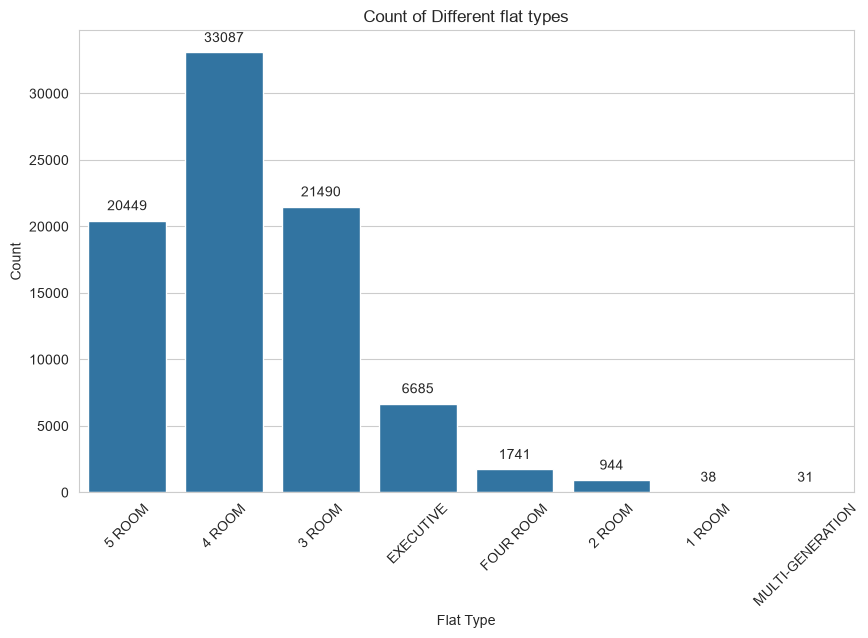

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# create bar chart to visualise the count of different flat types in the dataset
# set aesthetics style for the plot
sns.set_style("whitegrid")

# Bar chart for flat type with annaotations
plt.figure(figsize=(10, 6))
count_plot = sns.countplot(x='flat_type', data = df)
plt.title('Count of Different flat types')
plt.xlabel('Flat Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Annotate the bars with counts
for p in count_plot.patches:
    count_plot.annotate(format(p.get_height(),  '0.0f'),
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha = 'center', va = 'center',
                        xytext = (0, 10),
                        textcoords = 'offset points')
plt.show()

#### interpretation of bar chart
- the most common flat types are 4 room which is then followed by 3 rooms  and then 5 room. 1 room and multi-generaion flats are the least common 
- from the chart it also shows some data inaccuraties where by there is both '4 room' and 'FOUR ROOM' categories in the dataset. Here since they mean the same we can later join both categories together. This suggests the importance of cleanning the data as well. 

In [11]:
df['flat_type'] = df['flat_type'].replace({'FOUR ROOM': '4 ROOM'})

In [12]:
# verfify the changes 
print(df['flat_type'].value_counts())

flat_type
4 ROOM              34828
3 ROOM              21490
5 ROOM              20449
EXECUTIVE            6685
2 ROOM                944
1 ROOM                 38
MULTI-GENERATION       31
Name: count, dtype: int64


### Histogram
- another type of bar chart that represents the distribution of a dataset by looking into the frequency of data in a specific intervals.  

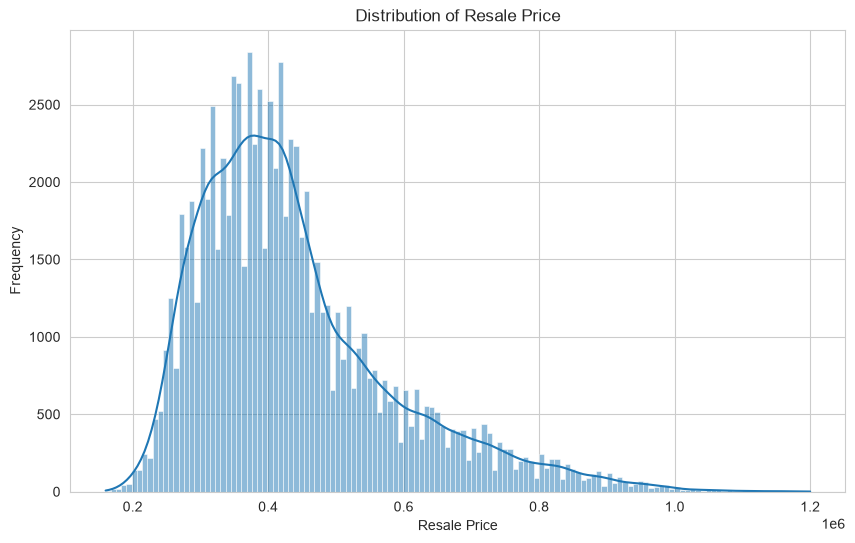

In [13]:
# set the aesthetics style for the plot
sns.set_style("whitegrid")

# histogram for resale price
plt.figure(figsize=(10, 6))
sns.histplot(df['resale_price'], kde = True)
plt.title('Distribution of Resale Price')
plt.xlabel('Resale Price')
plt.ylabel('Frequency')
plt.show()


### interpretation of the histogram
- from the chart we can see some key observation 

1. there is a central tendency that says the dataset is clustres around the central range. The mean resale price is estimated to $43,810 and the median is $408,000. Which indicates that hald of the properties have resale price below the median range and half of them are above the median price. 

2. variability and spread; the price within the relsale market varies as can be seen from the standard deviation of $146,782 and the price ranges from minimum of $160,000 to maximum of $1,200,000

3. Peak and common price; the comon resale price mode is $380,000 which is where the highest peak of the histogram lies, the price point in which is the most frequence amongst the properties in teh dataset

4. Skewness the distribution of the chart is rightly skewed meaning there are higher price properties that extend the tail on the right side causing the bulk of data to be concentrated to the lower end of the price

### Line chart
- displays series of data point called as markers that is connected by straight line segments one of the simplest and most effective way to show changes over time 

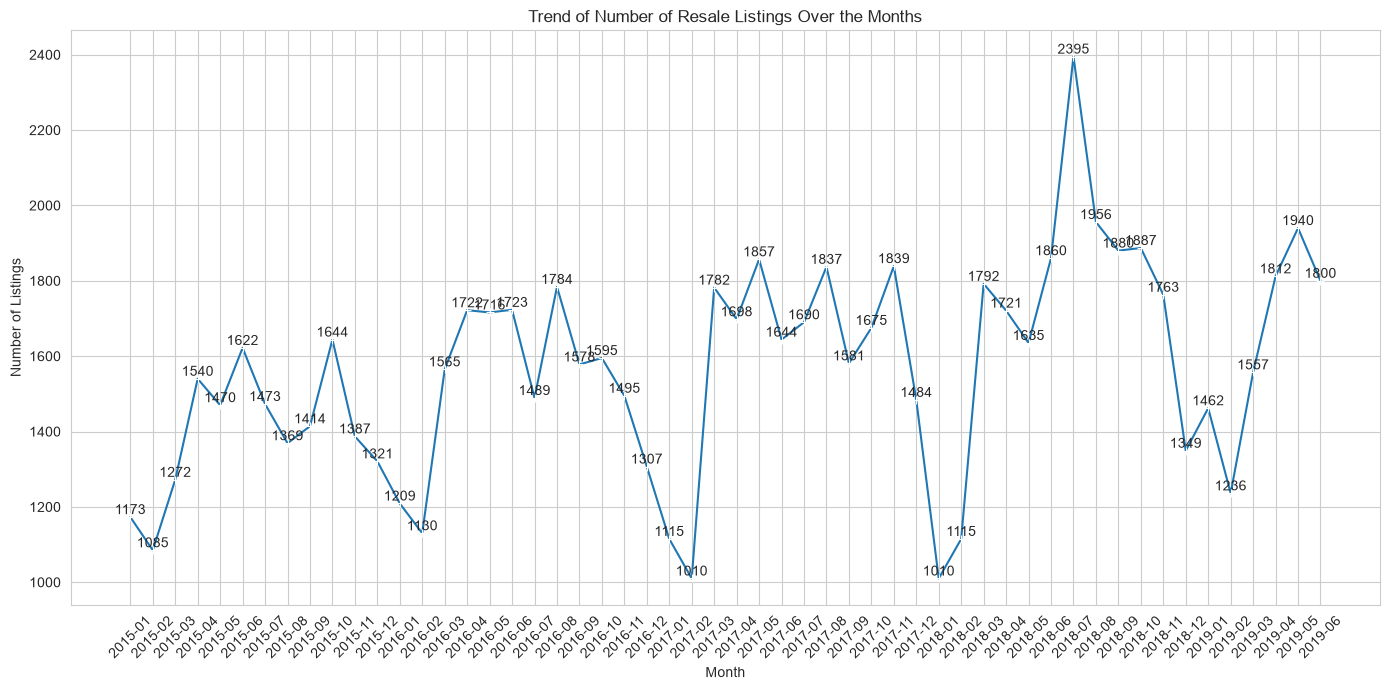

In [14]:
# Set the aesthetics style for the plot
sns.set_style("whitegrid")

# Count the number of listing by month 
month_counts = df['month'].value_counts().sort_index()

# create the line chart
plt.figure(figsize=(14, 7))
line_plot = sns.lineplot(x = month_counts.index, y = month_counts.values, marker = '+')

# Annotate the line chart with counts
for x, y in zip(month_counts.index, month_counts.values):
    plt.text(x,y, f'{y}', ha = 'center', va = 'bottom')

# label the chart
plt.title('Trend of Number of Resale Listings Over the Months')
plt.xlabel('Month')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### interpreting the line chart
1. monthly variations the chart display fluctations of resale listing across different months each point on the line chart represents the count of resale listed for that month with exact numbers annotated. there are 54 months displayed here

2. peaks and troughs; in july of 2018 the high number of listiting is displayed indicating a peak in resale activities. upon futher investigation this to be the highest since 2012. Probably due to "HDB flat owners’ increased willingness to meet buyers' offers due to concerns over lease decay and asset depreciation". The lowest listing compared to other months are feb 2017 and jan of 2018

3. seasonal trends 

## BIVARIANTE ANALYSIS
- analysis between 2 vairables and examine their relationship statistically

### Box Plot
- finds the relationship between categorical and numerical features 

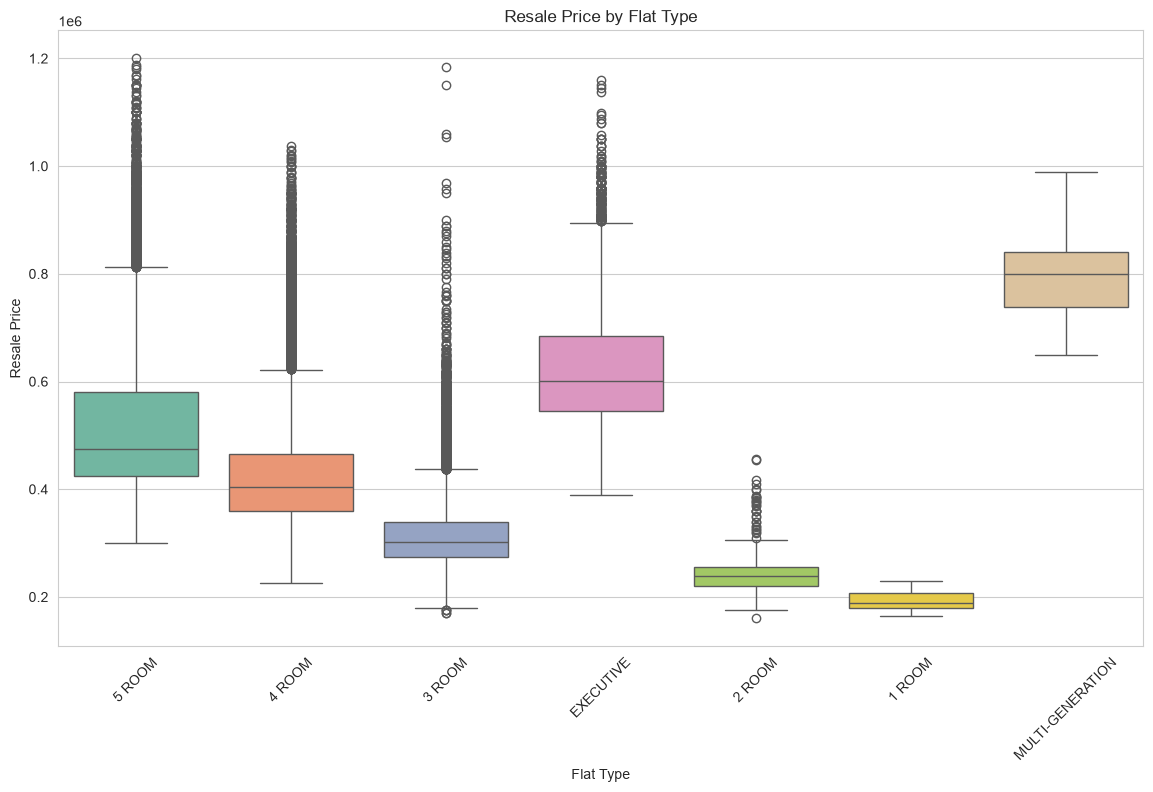

In [15]:
# relationship between flat_type and resale price

#set the aesthetics style for the plot
sns.set_style("whitegrid")

# Box Plot for flat type and resale price
plt.figure(figsize=(14, 8))
sns.boxplot(x='flat_type', y='resale_price', data=df, hue='flat_type', palette='Set2')
plt.title('Resale Price by Flat Type')
plt.xlabel('Flat Type')
plt.ylabel('Resale Price')
plt.xticks(rotation=45)
plt.show()


### Interpreting Box PLot
1. The price distrubution which displays lowest being 1 room followed by 2 room, 3 room, 4 room, 5 room, executive and multi-generation.  smaller flats such as 1 room and 2 room have lower and compact price distribution compared to other flat types. 

2. Median resale prices increases with the type of flat type which is as expected, the larger the flats are price tend to increase. Highest median is found in executive and multigenration flat types

3. IQR, which is the range between 25th and 75th percentiles, its wider for the larger dlats such as executive and multi-genrations suggests the greater variability in resale price for these flat types. Smaller flats such as 1 room and 2 room have narrower IQRs indicating the price are more consisdent 

4. Outliers there is a presence of outlier in 2 room, 3 room, 4 room, 5 room and executive flats. These outliers represents transactions that deviate signifficatly from general pricing trend, possibility due to unique feature of high demand in certain areas. 




### Bar Chart

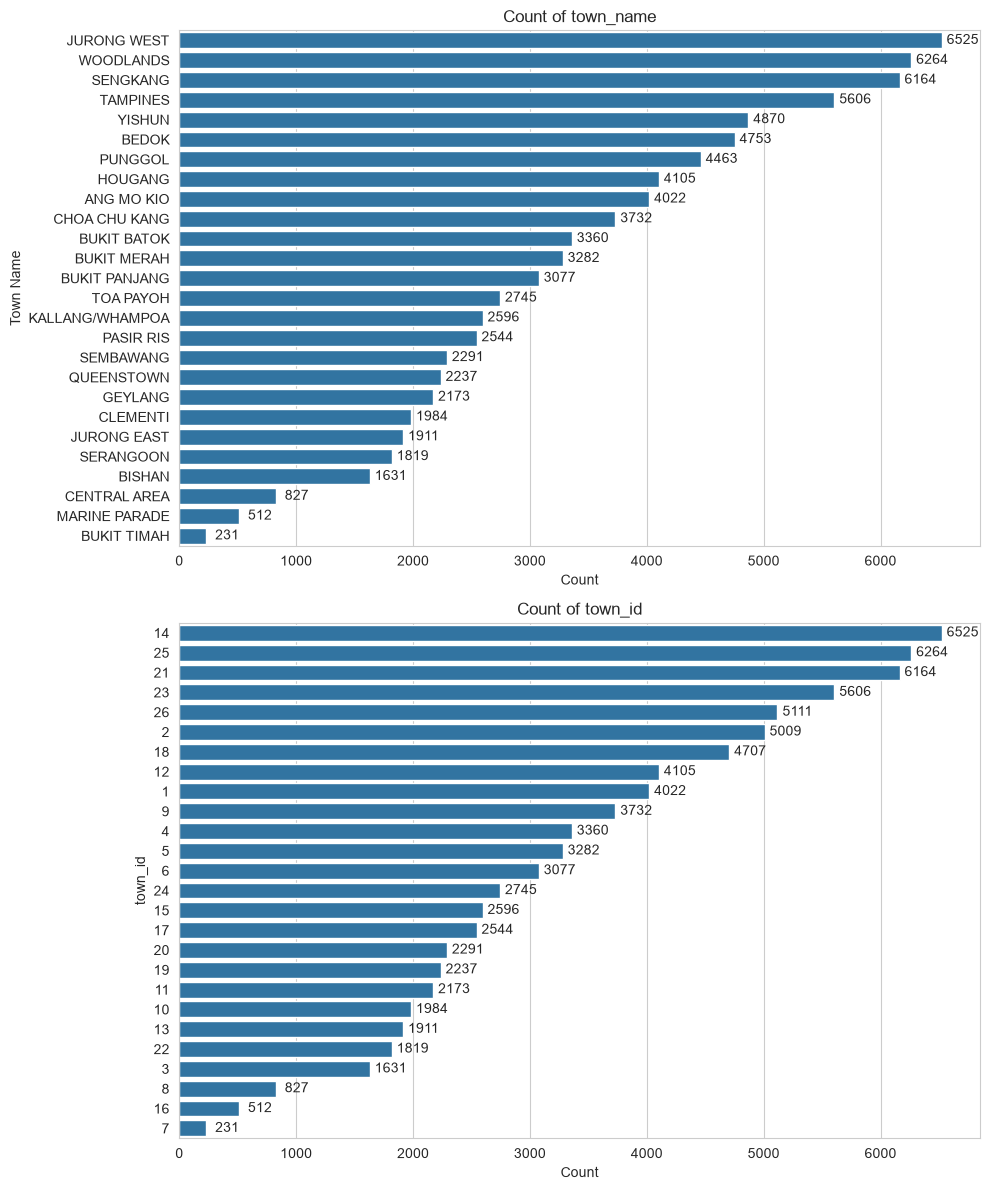

In [16]:

# set the aesthetics style for the plot
sns.set_style("whitegrid")

# create a figure with 2 subplots (onbe above another)
fig, axes = plt.subplots(2, 1, figsize=(10, 12))

# sort thw town_name by count 
sorted_town_name = df['town_name'].value_counts().index

# count plot for town_name with annotations
count_plot_1 = sns.countplot(y='town_name', data = df, order = sorted_town_name, ax=axes[0])
axes[0].set_title('Count of town_name')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Town Name')

# Annotate the bars with the frequency count
for p in count_plot_1.patches:
    count_plot_1.annotate(format(p.get_width(), '.0f'),
                          (p.get_width(), p.get_y() + p.get_height() / 2),
                          ha='center', va='center',
                          xytext=(15, 0),
                          textcoords='offset points')

# sort the town_id by count 
sorted_town_id = df['town_id'].value_counts().index

# Count plot for town_id with annotations 
count_plot_2 = sns.countplot(y = 'town_id', data = df, order = sorted_town_id, ax = axes[1])
axes[1].set_title('Count of town_id')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('town_id')

# Annotate the bars with the frequency count
for p in count_plot_2.patches:
    count_plot_2.annotate(format(p.get_width(), '.0f'),
                          (p.get_width(), p.get_y() + p.get_height() / 2),
                          ha='center', va='center',
                          xytext=(15, 0),
                          textcoords='offset points')

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the combined plot
plt.show()



### Interpreting subplot bar charts

1. ANomaliues frequencie of towns Yishun, Bedok and Punggol does not match frequencies of the respective numerical identifiers that is 26, 2 and 18 respectively. This suggest possible discrepancy where there are possible missing value

2. Trends the towns with highest number of resale unites are jurong west, woodlands and senkang. These areas demonstate a higher demand or turnover of resale properties. simialrly there are significantly lower number of resale transaction indicating either lower demand or smaller housing stock avaliable for resale.

### Scatter plot 

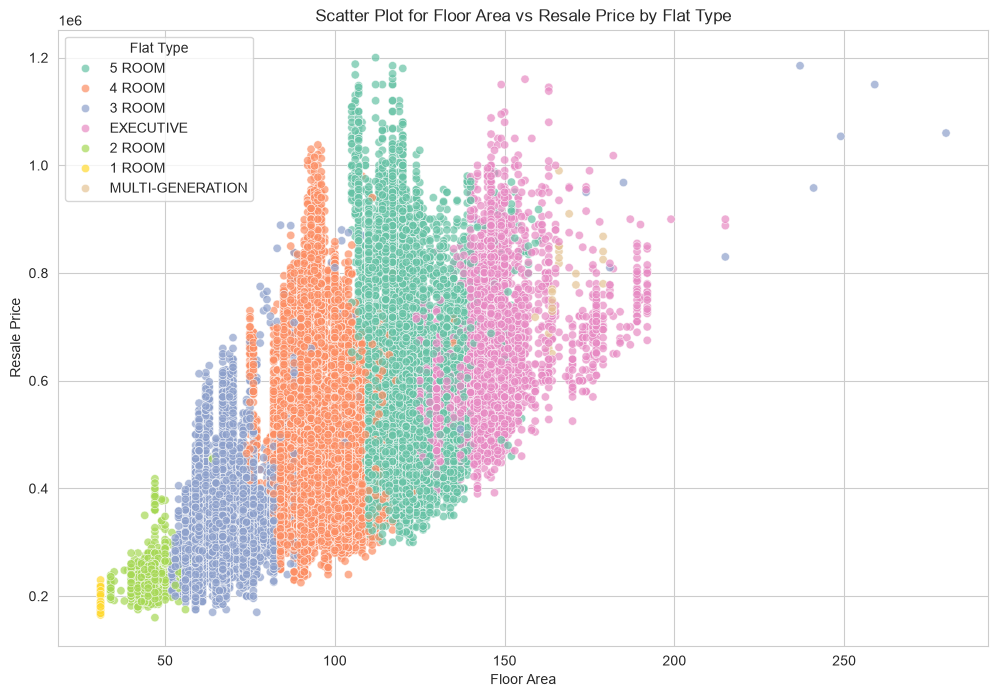

In [17]:
# set the aesthetics style for the plot
sns.set_style("whitegrid")

# Scatter plot for the floor area vs resale price with color encoding for flat type
plt.figure(figsize=(12, 8))
sns.scatterplot(x='floor_area_sqm', y='resale_price', hue='flat_type', data=df, palette='Set2', alpha=0.7)
plt.title('Scatter Plot for Floor Area vs Resale Price by Flat Type')
plt.xlabel('Floor Area')
plt.ylabel('Resale Price')
plt.legend(title = 'Flat Type')
plt.show()

### Interpresting scatter plot 

1. Trend observation the chart sugest postive trend indicating that floor area increase the price generaly increases. Suggest the larger flats tends to sell for higher prices 

2. Flat type distinction
the different plats are color codded thus allowing us to observer that larger flats such as executive and multi-generation flats tends to cluster towards higher floow areas and reslae price smaller flat type such as 1 room or 2 room clyuster towards lower floor areas and resale prices,

3. spread and distrubution the plot shows a wide spread of resaleprice for similar floor areas this could be due to othe factors influensing the resale prie such as location, age of the flat and the condition.

4. outlier and variability
a fewer data point stand out as outlioer with significantly higher resale prices compared tp others with similar floor ares this could be uniqie cases for flats or highly sought after locations. Worth further investivationb

In [18]:
# Filter the data for outliers
outliers = df[(df['flat_type'] == '3 ROOM') & 
                        (df['floor_area_sqm'] > 150) & 
                        (df['resale_price'] > 800000)]

# Display the outliers
outliers

,id,month,flat_type,block,street_name,storey_range,floor_area_sqm,lease_commence_date,remaining_lease,resale_price,town_id,flatm_id,town_name,flatm_name
856,857,2018-09,3 ROOM,41,JLN BAHAGIA,01 TO 03,237.0,1972,52 years 10 months,1185000.0,15,19,KALLANG/WHAMPOA,Terrace
7472,7473,2018-06,3 ROOM,58,JLN MA'MOR,01 TO 03,174.0,1972,53 years 02 months,950000.0,15,19,KALLANG/WHAMPOA,Terrace
31858,31859,2015-03,3 ROOM,53,JLN MA'MOR,01 TO 03,280.0,1972,56,1060000.0,15,19,KALLANG/WHAMPOA,Terrace
47739,47740,2017-12,3 ROOM,65,JLN MA'MOR,01 TO 03,249.0,1972,53 years 07 months,1053888.0,15,19,KALLANG/WHAMPOA,Terrace
51992,51993,2018-05,3 ROOM,44,JLN BAHAGIA,01 TO 03,185.0,1972,53 years 02 months,968000.0,15,19,KALLANG/WHAMPOA,Terrace
54578,54579,2016-12,3 ROOM,57,JLN MA'MOR,01 TO 03,259.0,1972,54,1150000.0,15,19,KALLANG/WHAMPOA,Terrace
61997,61998,2017-05,3 ROOM,59,JLN MA'MOR,01 TO 03,181.0,1972,54 years 02 months,810000.0,15,19,KALLANG/WHAMPOA,Terrace
66428,66429,2017-06,3 ROOM,38,JLN BAHAGIA,01 TO 03,215.0,1972,54 years 01 month,830000.0,15,19,KALLANG/WHAMPOA,Terrace
78787,78788,2015-06,3 ROOM,60,JLN BAHAGIA,01 TO 03,241.0,1972,56,958000.0,15,19,KALLANG/WHAMPOA,Terrace


In [19]:
# Further filter the data for 3-room terrace flats
terrace_outliers = df[(df['flat_type'] == '3 ROOM') & 
                        (df['flatm_name'] == "Terrace")]

# Display the outliers
terrace_outliers.describe().T

,count,mean,std,min,25%,50%,75%,max
id,48.0,48168.062500,22777.117131,857.0,31793.75,51140.5,65752.50,83890.0
floor_area_sqm,48.0,117.708333,55.604974,78.0,83.00,93.0,113.25,280.0
lease_commence_date,48.0,1889.166667,569.171078,-1972.0,1972.00,1972.0,1972.00,1972.0
resale_price,48.0,813840.685000,122974.848464,635000.0,730000.00,795000.0,871250.00,1185000.0
town_id,48.0,15.666667,1.506487,15.0,15.00,15.0,15.00,19.0
flatm_id,48.0,19.000000,0.000000,19.0,19.00,19.0,19.00,19.0


### Observations for outliers 
1. Identification of Terrace Houses

We discovered that the outlier 3-room flats are terrace houses, with 48 of them listed for sale. Additional research on such flats indicates that these terrace houses are HDB public landed properties that the government has discontinued. There were previously a total of 285 HDB terrace houses built in the Whampoa and Queenstown areas in the 1950s. These terrace houses typically feature living spaces spread across two storeys and include a backyard, which contributes to their larger floor areas. Additionally, like other HDB properties, all of these terrace houses have a 99-year lease.

2. Resale Price

The resale prices for these terrace houses vary significantly. The cheapest is listed at $635,000, while the most expensive is listed at $1,185,000.

3. Floor Area

There is a wide range in floor area among these terrace houses. The smallest terrace house has a floor area of 78 square meters, while the largest spans 280 square meters.

## CORRELATION ANALYSIS
discovering strength of associations, measure strength and direction of relationship between pair of features. 






Pearson Correlation Coefficient
The Pearson correlation coefficient, denoted as r , measures the linear relationship between two continuous variables . It ranges from -1 to 1, where:

r = 1 indicates a perfect positive linear relationship. ➕

r = -1 indicates a perfect negative linear relationship. ➖

r = 0 indicates no linear relationship. 🚫

Pearson correlation assumes that the data is normally distributed and that the relationship between the variables is linear. It's widely used due to its simplicity and ease of interpretation, especially in fields like finance, social sciences, and natural sciences.

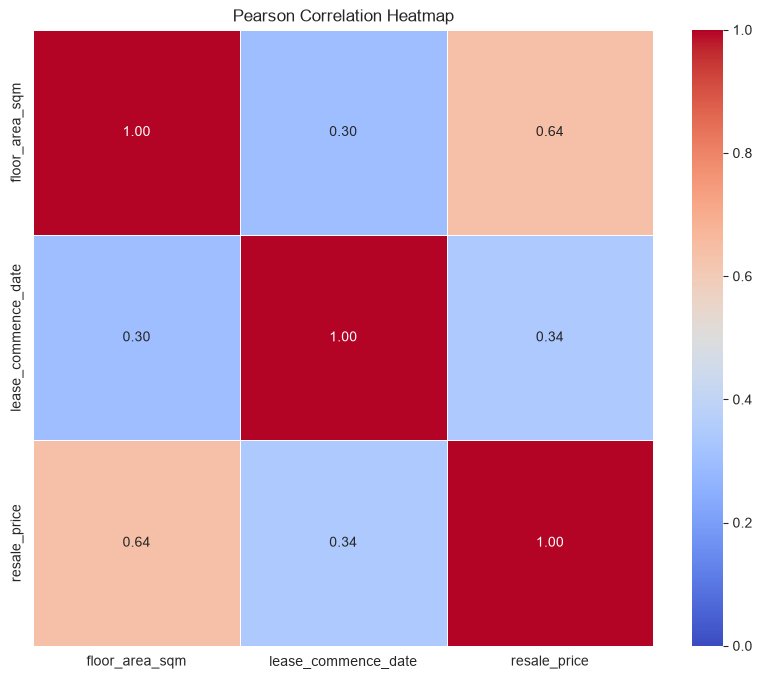

In [20]:
# Absolute negative years values
df['lease_commence_date'] = df['lease_commence_date'].abs()  
  
# Select continuous variables  
continuous_vars_all = df[['floor_area_sqm', 'lease_commence_date', 'resale_price']]

# Calculate the Pearson correlation matrix for the entire dataset
corr_matrix_pear = continuous_vars_all.corr(method='pearson')

# Plot the heatmap of the correlation matrix for the entire dataset
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_pear, annot=True, cmap='coolwarm', vmin=0, center=0.5, vmax=1, linewidths=0.5, fmt=".2f")
plt.title('Pearson Correlation Heatmap')
plt.show()

### interpreting pearson correlation coefficent 
- there is a strong correlation of 0.64 between "floor area sqm" and "resale price" suggesting that the larger floor areas are associated with higher resale price 

- there is a moderate positive correltion between the elase commence data dn resale price indicating that the properties with longer remianing lekases tends to have higher resale price. 

there are several limitation as person coefficent is designed for continous variables, pearson correlation assumes that the relationship between variables are linear and may not capture the strength or directions of non-linear relationships. Adding on person correlation also assumps normality, in which cases assumes the data is normally distributed. Pearson's correlation assumes that the spread or variance of the data points is constant across the entire range of values (this is called homoscedasticity). Think of it like having a basketball court where the floor is perfectly flat. Pearson's correlation is sensitive to outliers. Extreme values can disproportionately influence the correlation coefficient, leading to misleading results. Even a few outliers can significantly distort the measure of the overall relationship between the variables.

###  Spearman rank correlation coefficient

The Spearman rank correlation coefficient, denoted as ρ (rho) , measures the strength and direction of the monotonic relationship between two ranked variables . It ranges from -1 to 1, where:

ρ = 1 indicates a perfect positive monotonic relationship. ➕

ρ = -1 indicates a perfect negative monotonic relationship. ➖

ρ = 0 indicates no monotonic relationship. 🚫

Spearman correlation does not assume that the data is normally distributed and can be used with ordinal, interval, or ratio data. It's especially useful when the relationship between variables is not linear but still monotonic. A monotonic relationship between two variables means that as one variable increases, the other variable either consistently increases or consistently decreases, but not necessarily at a constant rate. In other words, the relationship does not have to be linear (straight-line), but it must be one-directional.

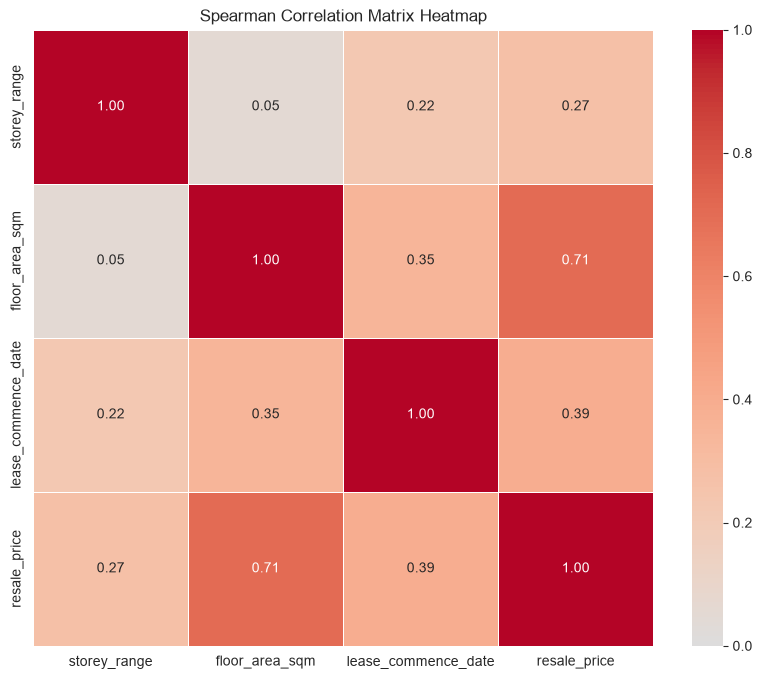

In [21]:
# Function to convert storey_range to ordinal scale by taking the average of the range
def convert_storey_range(storey_range: str) -> float:
    """
    Converts a storey range string into its average numerical value.
    
    The function takes a storey range in the format 'XX TO YY', splits it into two parts,
    converts these parts to integers, and returns the average of these integers.
    
    Args:
        storey_range (str): A string representing a range of storeys, in the format 'XX TO YY'.
        
    Returns:
        float: The average value of the two storeys in the range.
        
    Example:
        convert_storey_range('07 TO 09') -> 8.0
    """
    range_values = storey_range.split(' TO ')
    return (int(range_values[0]) + int(range_values[1])) / 2

# Use the .apply() method to convert the 'storey_range' column with the function
df['storey_range'] = df['storey_range'].apply(convert_storey_range)

# Select relevant columns for correlation analysis
spearman_vars = df[['storey_range', 'floor_area_sqm', 'lease_commence_date', 'resale_price']]

# Compute the Spearman correlation matrix
spearman_corr = spearman_vars.corr(method='spearman')

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', center=0, vmin=0, vmax=1, linewidths=0.5, fmt=".2f")
plt.title('Spearman Correlation Matrix Heatmap')
plt.show()

### interpreting Spearman Rank Correlation cofficent 
Interpreting Spearman Rank Correlation Coefficient
In the Spearman correlation matrix plotted above, we can make several key observations about the correlations in the features chosen.

There is a strong positive monotonic correlation between the 'floor_area' and the 'resale_price'. Larger flats tend to have higher resale prices, and this relationship is relatively strong. 

There is a moderate positive monotonic relationship between the 'lease_commence_date' and the 'resale_price'. Flats with more recent lease commencement dates tend to have higher resale prices. 

There is a weak positive monotonic correlation between the 'storey_range' and the 'resale_price'. Higher storey flats tend to have higher resale prices, but the relationship is not strong.

There are also several limitation such as it assumes that the data is ordinal and not suitable for normimal data where there is no order. Only measures monotonic relationship it assess the strength of monotonic relationshop if the relationship between variables is not monotonic the spearman correlation may not capture the true nature of the relationship. Insensitive to linear relationship indicates that high correlation for non linear but monotonic relationsjoip. it might not be able to detect strong linear relationshhip if its not perfectly monotonic. Since the spearman correlation is based on ranks it ignore the actual magniture of the values this can lead to loss of information. Finally its less sensitive to distribution. 

# 2. DATA CLEANING AND PREPROCESSING

### Data cleaning
- Very important in ML lifecycle helps improve the data quality. Since raw data often contains error, inconsistencies. Cleanning data helps identify and correct these issues. Ensuring the data is accurate, consistent and reliable. 
- enhances model performance, clean data helps creating model that generalise well to new and unseen data. By removing the noise and irrelevant information it allows themodel to learn the true pattern in the data and improve accuuracy
- reduce bias and variance; dirty data can introduce bias and variance into model. Leading the model to overfitting or underfitting. Cleanning data reduces such risks. 
- Facilitates Data integeration. In many project data comes from multiple souces cleaning data ensure that all data can be integerated seamlessly.
- Cleaning data ensure that the data complies with regulatory standards and internal data governance. 

### Steps in data cleaning 
- Correcting structural error: these are the structural error such as inconsistencies and inaccuraies in the data's format and organization. These errors can arise from various sources. 
    - Standardizing Formats: Ensuring that data is consistently formatted, such as dates being in the same format throughout the dataset.
    - Correcting Typos and Misspellings: Identifying and correcting typographical errors and misspelled words, which can cause inconsistencies.
    - Ensuring Consistent Naming Conventions: Standardizing names and labels to avoid discrepancies. For example, ensuring that 'New York' is not listed as both 'NY' and 'New York City'.
    - Resolving Data Type Issues: Ensuring that each column in the dataset has the correct data type (e.g., numeric, string, date) to prevent errors during analysis. 
- Missing values are a common issue in datasets and can significantly impact the performance of machine learning models if not addressed properly. Handling missing values involves:
    - Identifying Missing Data: Determining which values are missing and understanding the extent of the problem.
    - Imputation: Replacing missing values with substituted values. Common imputation methods include using the mean, median, or mode for numerical data, and the most frequent category for categorical data. Always investigate if missing values can be imputed by inferring from other columns.
    - Dropping Missing Values: In some cases, it may be appropriate to remove rows or columns with missing values, especially if the proportion of missing data is too large. However, dropping data should always be the last resort.
    - Using Advanced Imputation Techniques: For more complex datasets, advanced techniques such as k-nearest neighbors (KNN) imputation or model-based imputation may be used.

- Not all data in a dataset is useful for analysis. Removing unnecessary or unwanted data helps streamline the dataset and focus on the most relevant information. This step involves:

    - Dropping Irrelevant Features: Removing columns that do not contribute to the analysis or model. For example, an ID column may not be relevant for predicting customer behavior.
    - Removing Duplicate Entries: Identifying and removing duplicate rows to avoid redundancy and ensure that each data point is unique.
    - Filtering Out Noise: Eliminating outliers or data points that do not represent the typical behavior or distribution of the dataset, which can distort analysis and model training.
    - Addressing Irrelevant Data Points: Removing rows that do not fit the context of the analysis. For example, excluding data from a specific time period that is not relevant to the study.
    - Dropping Post-hoc Features: Removing columns that will not be available at the time of prediction, sometimes referred to as post-hoc or leaky data. Including them in the model would be like using information from the future - it would make our model seem more accurate than it really is. For example, since we are predicting the 'resale_price' of HDB flats, we should exclude features like 'resale_price_USD', as this is just a converted version of the target variable and won't be available during prediction. Removing such features will prevent data leakage and ensure the model's performance is realistic and reliable.

### Correcting Structural Errors
1. Handling Negative Values
- for the variable 'lease_commence_date' using the .describe() function negative values were found
2. Standardising Categorical Labels
-  inconsistency in the 'flat_type' feature when visualising data with a univariate bar chart. Specifically, the feature contained both '4 ROOM' and 'FOUR ROOM' categories, 

In [22]:
# 1. Handling Missing Values

# Absolute negative years values
df['lease_commence_date'] = df['lease_commence_date'].abs()

# 2. Standadising the categorical variables

# replace 'FOUR ROOM' with '4 ROOM' in the flat_type column
df['flat_type'] = df['flat_type'].replace({'FOUR ROOM': '4 ROOM'})

### Handling Missing Values 
- discovered there are missing value specifically in variables "town_name", "flat_name" they had 783 and 514 null values respectively after further investigation in BIVARIATE ANALYSIS where sub barplot were visualised the variables "town_name" and "town_id" has some dispirencies in frequencies with Yishun, Bedok and Punggol. As such imputing the town_name and their town_id is a good approach. Similarly same imputation can be done to other id columns

In [23]:
def fill_missing_names(df: pd.DataFrame, id_column: str, name_column: str) -> pd.DataFrame:
    """
    Fills missing values in the 'name_column' using the 'id_column'.

    Args:
        df (pd.DataFrame): The DataFrame containing the columns to be filled.
        id_column (str): The name of the column containing the IDs.
        name_column (str): The name of the column containing the names to be filled.

    Returns:
        pd.DataFrame: The DataFrame with missing values in 'name_column' filled.
    """
    # Identify missing values in the 'name_column'
    missing_names = df[name_column].isna()

    # Create a dictionary mapping 'id_column' to 'name_column'
    name_mapping = df[[id_column, name_column]].dropna().drop_duplicates().set_index(id_column)[name_column].to_dict()

    # Fill missing 'name_column' using the mapping
    df.loc[missing_names, name_column] = df.loc[missing_names, id_column].map(name_mapping)

    return df

In [24]:
# Fill missing values in 'town_name' column
df = fill_missing_names(df=df, id_column='town_id', name_column='town_name')

# Fill missing values in 'flatm_name' column
df = fill_missing_names(df=df, id_column='flatm_id', name_column='flatm_name')

### Removing Unnecessary Data
1. Dropping Duplicates
2. Dropping Irrelevant Features
- id columns are not needed after the where imputed in to name columns

In [25]:
#1. Dropping Duplicates
df.drop_duplicates(inplace=True)
#2. Dropping Irrelevant Features
# Drop irrelevant features
df = df.drop(columns=['id', 'town_id', 'flatm_id'])

## FEATURE ENGINEERING
- extract meaningful features from raw data involves creating, transforming, or selecting features that will help ML to perfrom better

- Feature engineering is crucial because:
    - It enhances model performance as such good features can boost the performance and how efficent the ml models will be
    - the features will be more interpretable and actionable
    - reduce overfitting and allow the model to generalise better to unseen data and reduce the risk of overfitting. 
    - Helps simplifying and structuring the data. 
    



1. Feature engineering "Month"
    - the variable month has both year and month and is stored as string object
        - as such we are changing its format to datetime 
        - extract year 
        - extract month 

In [26]:
# Convert month column to datetime format
df['year_month'] = pd.to_datetime(df['month'], format='%Y-%m')

# extract year and month 
df['year'] = df['year_month'].dt.year
df['month'] = df['year_month'].dt.month

df.head()

,month,flat_type,block,street_name,storey_range,floor_area_sqm,lease_commence_date,remaining_lease,resale_price,town_name,flatm_name,year_month,year
0,5,5 ROOM,118,PASIR RIS ST 11,8.0,123.0,1989,70 years 03 months,488000.0,PASIR RIS,Improved,2018-05-01,2018
1,10,4 ROOM,101,RIVERVALE WALK,2.0,100.0,1999,81,345000.0,SENGKANG,Model A,2016-10-01,2016
2,10,5 ROOM,688A,CHOA CHU KANG DR,20.0,110.0,2002,82 years 06 months,370000.0,CHOA CHU KANG,Improved,2018-10-01,2018
3,12,4 ROOM,130,LOR AH SOO,14.0,103.0,1984,67,432000.0,HOUGANG,Model A,2015-12-01,2015
4,9,5 ROOM,533,SERANGOON NTH AVE 4,8.0,122.0,1992,74 years 02 months,500000.0,SERANGOON,Improved,2017-09-01,2017


In [27]:
# after feature engineering, we can drop the original month column as it is no longer needed
df = df.drop(columns=['year_month'])

2. Feature engineering "remaining_lease_month"
Currently stored as object and is hard for ML models to handle and there are several inconsistent formats as such:
     - convert to numerical format
     - check for inconsistencies 
     

In [28]:
import re

def extract_lease_info(lease_str: str) -> int:
    """"
    Convert lease information from a string format to total months

    This function takes a string representation which is teh remaining lease period
    that may include years and month in various formats and convert it to total months. 
    For example, "99 years 11 months" will be converted to 1199 month
    
    Args: 
        lease_str (str): A string representing the remaining lease period.
        
    Returns:
        int: Total months of the remaining lease period. If the input is invalid or empty, returns 0.
    """

    if pd.isna(lease_str):
        return None

    #regular expression to extract the year and the month 
    years_match = re.search(r'(\d+)\s*years?', lease_str)
    months_match = re.search(r'(\d+)\s*months?', lease_str) 
    number_match = re.match(r'(\d+)', lease_str.strip())

    if years_match:
        years = int(years_match.group(1))
    elif number_match: # only if the number is present, assume it in years
        years = int(number_match.group(1))
    else:
        years = 0   

    months = int(months_match.group(1)) if months_match else 0

    # convert the total lease perpod to months
    total_months = years * 12 + months
    return total_months

In [29]:
df['remaining_lease_months'] = df['remaining_lease'].apply(extract_lease_info)
df[['remaining_lease', 'remaining_lease_months']].sample(5)

,remaining_lease,remaining_lease_months
12060,82,984
18235,74 years 02 months,890
56157,72,864
56606,60,720
18913,80,960


In [30]:
# after feature engineering is completed drop the original colummsn
df = df.drop(columns=['remaining_lease'])

3. Feature engineeirng "storey_range"
- in correlation analysis introduced convert story range to transform the og story range from string to numerical values . This is needed as storey range is ordional data and has meanigful rank order.  

```
def convert_storey_range(storey_range: str) -> float:
    """
    Convert a storey range string to its average numeric value.
    
    The function takes a story range in the format 'XX TO YY' splits it into two parts,
    converts these parts to integers, and return the average of these integers.

    Args:
        storey_range (str): A string representing the storey range in the format 'XX TO YY'.

    Returns:
        float: The average numeric value of the two storey range.
    
    Example:
        convert_storey_range('07 TO 09') -> 8.0
    """

    range_values = storey_range.split(' TO ')
    return (int(range_values[0]) + int(range_values[1])) / 2

# use the .apply() method to convert the storey_range column to numeric values
df['storey_range_numeric'] = df['storey_range'].apply(convert_storey_range)
```

### Advanced Feature engineering
- information such as block and streetname have their own columns its better to concatenate them to make a full address

In [31]:
# Drop the 'block' and 'street_name' columns
df = df.drop(columns=['block', 'street_name'])

## Data Splitting
- is a fundamental step in preparing your dataset for ml models 
- it helps preventing overfitting with testing we can assess if the model has learned the general pattern or memoriesed the traning data
- helps evaluating the ml performance accurately, by traning the model on one subset of data and testing it on another you can gauge how well it will perform on real world data 
- Hyperparameter tuning, validation set for tuning hyperparameters such as learning rate and the number of trees in a random forest or the number of layers in a neural network
- avoid data lekage 

### Feature Target seperation
we need to seperate the features that are dependent predictor variables from our traget variables which are dependet variable that we predict.

In [32]:
# seperate the data into deatures and target
X = df.drop(columns=['resale_price'])
y = df['resale_price']

In [33]:
X

,month,flat_type,storey_range,floor_area_sqm,lease_commence_date,town_name,flatm_name,year,remaining_lease_months
0,5,5 ROOM,8.0,123.0,1989,PASIR RIS,Improved,2018,843
1,10,4 ROOM,2.0,100.0,1999,SENGKANG,Model A,2016,972
2,10,5 ROOM,20.0,110.0,2002,CHOA CHU KANG,Improved,2018,990
3,12,4 ROOM,14.0,103.0,1984,HOUGANG,Model A,2015,804
4,9,5 ROOM,8.0,122.0,1992,SERANGOON,Improved,2017,890
...,...,...,...,...,...,...,...,...,...
84460,9,5 ROOM,11.0,111.0,2001,SEMBAWANG,Improved,2015,1020
84461,6,5 ROOM,8.0,110.0,2002,ANG MO KIO,Improved,2015,1032
84462,9,5 ROOM,2.0,110.0,2003,HOUGANG,Improved,2017,1018
84463,4,4 ROOM,2.0,91.0,1984,ANG MO KIO,New Generation,2016,792


In [34]:
y

0        488000.0
1        345000.0
2        370000.0
3        432000.0
4        500000.0
           ...   
84460    468000.0
84461    760000.0
84462    380000.0
84463    406000.0
84464    425000.0
Name: resale_price, Length: 84465, dtype: float64

### Train-Validation Data Splitting 
There are typically several ways we can split our data like this: 
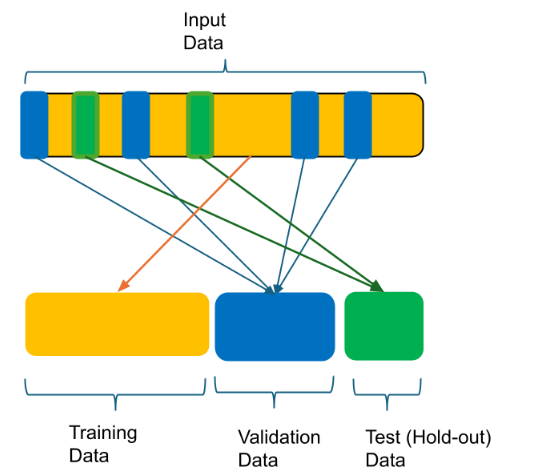



Any the splitting will be three ways as shown above

1. Traning data 
It is the set of data used to train the model where they learn patterns, trends, relationshop between input features and target variable.

2. Validation dataset
Following the traning dataset vvalidation comes into play coming as a mock exam and is used to fine tune the model and help select the best hyperparameters 

3. Test Dataset 
The final phase which involves test set that represents actual exam and used to acess the final performance of the model and how it can apply its ability to new and unseen data 

In [35]:
from sklearn.model_selection import train_test_split

# Split the data into training 80% annd test validation 20 sets 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Split the test validation set 20% into 10 % validation and 10% test sets
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

In [36]:
print("Training Set Size:", X_train.shape, y_train.shape)
print("Validation Set Size:", X_val.shape, y_val.shape)
print("Test Set Size:", X_test.shape, y_test.shape)

Training Set Size: (67572, 9) (67572,)
Validation Set Size: (8446, 9) (8446,)
Test Set Size: (8447, 9) (8447,)


## Feature Scalling
- important preprocessing step in ML that involves adjusting the range of values for different numerical features in your dataset. Ensure each numerical feature contributed queally to the model which is also preventing some features dominating others. 

    - Normalisation: resales the data to fall within a specified range of 0 and 1. Process ensures no single feature can dominate others due to scale and can improve the performance of ML algo using methods such as Min-Max normalisation.
        - When to use normalisation:
            - Distance-Based Algorithum: Algo that rely on distance calculation such as KNN and the K means clustering, they greatly benefit from normalisation.By normalising features each one conrtibutes equally ensing more balanced and accurate computation distance.
            - Gradient Descent Optimization: For models like neural networks and logistic regression which uses gradient descent for optimization, normalisation can significantly improve traning proces, speeds up the convergence of gradient descent which results in faster traning times. 
            - Equal importance of Feature: when you want each feature to have the same impact on the outcome, normalisation is essential ensure that no single feature dominates the model due to its scale leading for more balaced contribution from all features. 
        - Drawbacks of normalisation:
            - Loss of interpretability: one of the primary disadvantage of normalisation is that transformed data values losse their OG unit and scale. Making it more challenging to interpret the results.
            - Sensitive to Outlier: Min-Max nromalisation is sensitive to outliers, they can significantly affect the minimum and maximum values which would resullt in skewed normalisation. Leading to inaccurate representation of majority of data points
            - Not suitable for All algoithums: some ML, espicially tree based models like decision tress and random forest do not require normalisation these are not distance based calculation and inheritenly handle features of diffecnt scale. Normalising such data can be unnessary and may not improve model performance
    - Standardaization: transforms the data so that is has mean of zero and the Standard deviation of 1, as such reshaping the data to follow the standard normal distribution.This process ensures that each feature contributes equally to machine elarning model by centreing the data around the mean and scalling it by standard deviation. This is useful for algorithum to assume normally distributed data.
        - When to use Standadization:
            - Algorithums assuming normal distribution: Algorithum like linear regression and linear discriminant analysis assume that the input features are normally distributed. Standardization helps in meeting this assumption by centerin the features around the man and scalling them to have a standard deviation of one.
            - Distance-Based algorithum: Similar normalisation, standardization benefits distance-based algo such as KB , K means clustering. Standardization feature ensures that each one contributed equally to the distance clculation.
            - Gradient Descent Optimization: For models optimized using gradient descent, such as neural network, standardization can lead to faster convergence. This is because features with similar scales provide a more stable and efficent optimization path.

### Implementing Standardization
Let's proceed with standardizing the numerical features in the dataset. The numerical features we want to standardize are 'floor_area_sqm', 'remaining_lease_months', 'lease_commence_date', and 'year'.

After performing exploratory data analysis, we observed that these numerical features have nearly normal distributions but vary significantly in their scales. Standardization is particularly suitable here and justifiable because:

Distribution: The numerical features have approximately normal distributions.

Scales: The numerical features are on different scales, which can adversely impact the performance of machine learning algorithms if not addressed.

Algorithm Assumptions: The machine learning algorithms we plan to use later in the course (such as linear models) assume normally distributed data and are sensitive to feature scales, particularly those that rely on distance metrics.

The code below does the following:

Import Modules: 'Pipeline' from sklearn.pipeline  is used to create a sequence of data transformation steps. Standard Scaler from sklearn.preprocessing is the scaler standardizing features by removing the mean and scaling to unit variance.

Defining Numerical Features: Create a list containing the names of the numerical columns we want to standardize with the scaler.

Creating a Numerical Transformer Pipeline: 'Pipeline' function creates a pipeline of data transformation steps. The 'steps' parameter takes a list of tuples, where each tuple contains a name and a transformer (in this case, a standardization scaler). The tuple ('scaler', StandardScaler()) applies the Standard Scaler to standardize the numerical features. The name 'scaler' is a string identifier for this step, which can be referenced later if needed. Do note that we are just setting up the pipeline in the code below and have not actually applied the Numerical Transformer Pipeline to transform the data yet. There are still additional feature transformation steps we need to do in the next section before we can apply our pipeline to the data.

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

#define numerical feature to be standardized
numerical_features = [
    'floor_area_sqm',
    'remaining_lease_months',
    'lease_commence_date',
    'year'
]
# create numerical transformer pipeline for standardization
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

### Split then Scale
After preparing data for ML model, its important to perform scalling after splitting your data training, validation test sets
- avoid data lekage
- Real world simulation: model trained on historical data is used to make predictions on new unseen data. To simulate this scenario accurately during model development, you should ensure that the scaling parameters are derived only from the training data. This helps in assessing how well the model generalises to new data.
- Consistent scalling: by spliting the data first and then fitting the scaler on training data, you ensure that the same transformation is applied consistently scross the traning, validation and test set. The validation, test sets should only be transformed using parameters learned from traning set to maintain integreity of the model evaluation. 

## Feature encoding
Machine learning rely on mathematical computations which require numerical inputs. Datasets contains categorical features such as name, categories, or labels these are nonnumeric values they need to be converetd into number to be effectively used by model. Feature encoding bridges this gap also ensures that your modeol can make sense of all the information avaliable and perform optimally. The two most common techniques are:
    - one-hot encoding: this method creates a binary column for each category return matrix with 1s and 0s. useful when there is no oridinal relationshop between catgories such as colours instead of t-shirt sizes.
    - Ordinal Encoding, this method assigns a unique integer to each catgory whichis usefuul when there is a order or rank amongst these catgories such as t-shirt sizes. 

### One-hot Encoding
In our HDB resale price dataset, the features we want to one-hot encode are 'town_name', 'flatm_name', and 'month'.

The 'town_name' feature represents the name of the town where the HDB resale flat is located. Town names are nominal categories with no intrinsic order. One town name is not inherently greater or lesser than another. For instance, 'Ang Mo Kio' and 'Bedok' are just names of different towns with no ranking relationship.

The 'flatm_name' feature represents the model type of the HDB flat, such as 'Simplified', 'Type S2', 'Model A', and 'Premium'. Each flat model is a distinct type without any inherent hierarchy. However, it is possible that some flat models may be perceived as more exclusive or premium than others. For instance, a 'Premium' flat might be considered more desirable than a 'Simplified' flat due to better amenities or a more modern design. Despite this perception, there is no standardized ranking or order that can be universally applied to all of these categories. When the order is unclear, using one-hot encoding prevents the introduction of implicit bias that could mislead the machine learning models.

The 'month' feature represents the month of the resale transaction. Although months are usually processed cyclically using sine and cosine transformations, for simplicity, we will treat each month as a distinct category using one-hot encoding.  By one-hot encoding the months, we allow the model to learn patterns that are specific to each month without imposing a sequential order or any specific cyclic pattern.

One of the primary drawbacks of one-hot encoding is high dimensionality. When dealing with categorical features that have many unique categories, this method can lead to a very large number of columns, resulting in a sparse and computationally expensive dataset. High dimensionality increases the risk of overfitting (you will learn about this later), where the model learns noise and random fluctuations in the training data instead of the underlying patterns. This can lead to poor generalisation to new data. To mitigate this, dimensionality reduction techniques like feature hashing can be employed to reduce dimensionality. Another approach is to combine rare categories into a single 'Other' category, thereby decreasing the number of unique values.

### ordinal encode
The 'flat_type' feature indicates the type of the HDB flat, such as '1-room', '2-room', '3-room', '4-room', '5-room', 'Executive', and 'Multi-generation'. Flat types can be considered to have a natural ranking based on their size and number of rooms. For instance, a '1-room' flat is smaller and generally considered lower in rank compared to a '5-room' flat. By ordinally encoding 'flat_type', we assign a unique integer to each category in a way that reflects this inherent order.

The 'storey_range' feature represents the range of floors on which the flat is located, such as '01 TO 03', '04 TO 06', and '07 TO 09'. The 'storey_range' feature naturally represents an ordinal scale, as higher floor ranges can be considered better or more desirable in some contexts. This feature has already been ordinally encoded during our exploratory data analysis (EDA) in the Correlation Analysis unit by converting ranges like '07 TO 09' to their midpoints (e.g., 8.0). Therefore, there is no need to encode 'storey_range' again. This previous transformation ensures that the data is already in a numerical format suitable for model training.

One potential drawback of ordinal encoding is the imposed order. This method assumes a meaningful order and equal spacing between categories, which might not always be appropriate. For example, the difference between "low" and "medium" may not be the same as between "medium" and "high." To mitigate this issue, it is essential to validate that the ordinal relationship makes sense for your data. If the order is not appropriate, consider using one-hot encoding or another suitable method.

Another drawback is the possibility of misinterpretation. Ordinal encoding can lead models to make incorrect assumptions about the relationships between categories if the order does not hold true significance. To address this, carefully analyse and preprocess your data to ensure that the ordinal encoding reflects the true nature of the categories. Utilise domain knowledge to confirm the order and ensure it is meaningful for the model's interpretation.




In [38]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# Define nominal features to be one-hot encoded
nominal_features = ['month', 'town_name', 'flatm_name']

# Define ordinal features to be ordinally encoded
ordinal_features = ['flat_type']

# Define the ordinal categories for flat_type
flat_type_categories = [
    '1 ROOM',
    '2 ROOM',
    '3 ROOM',
    '4 ROOM',
    '5 ROOM',
    'MULTI-GENERATION',
    'EXECUTIVE'
]

# Define passthrough features
passthrough_features = ['storey_range']

# Create nominal transformer pipeline
nominal_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create ordinal transformer pipeline
ordinal_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(
        categories=[flat_type_categories],
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

### Combined Feature Scalling and Encoding 
Now, we will integrate the pipelines we created for feature scaling and feature encoding into a Column Transformer. This tool allows us to apply different preprocessing steps to different subsets of columns within our dataset.

A Column Transformer is a powerful tool provided by Sklearn that enables you to apply multiple transformations to different columns of a dataset simultaneously. Column Transformer allows you to specify distinct preprocessing steps for different subsets of columns. This is particularly useful when you need to apply different types of transformations (such as scaling, encoding, and passing through) to different features.

The code below does the following:

Import Modules: Import Column Transformer class from Sklearn's compose module.

Combining Transformers: The Column Transformer class has a parameter 'transformers', which takes a list of tuples, where each tuple specifies a transformer to be applied. Each tuple consists of a string identifier for the transformer, the transformer object itself, and the list of columns to which the transformer should be applied. The 'remainder' parameter specifies what to do with the remaining columns that are not explicitly mentioned in the transformers list. Setting this to 'passthrough' ensures that columns not listed in transformers are passed through without transformation. However, we have already accounted for all the columns in our dataset within our transformer pipelines. The 'n_jobs' parameter specifies the number of jobs to run in parallel for the transformers. Setting it to -1 uses all available processors, speeding up the transformation process.

In [39]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('nom', nominal_transformer, nominal_features),
        ('ord', ordinal_transformer, ordinal_features),
        ('pass', 'passthrough', passthrough_features)
    ],
    remainder='passthrough',
    n_jobs=-1
)

In [40]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('nom', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",-1
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feat

In another image: 



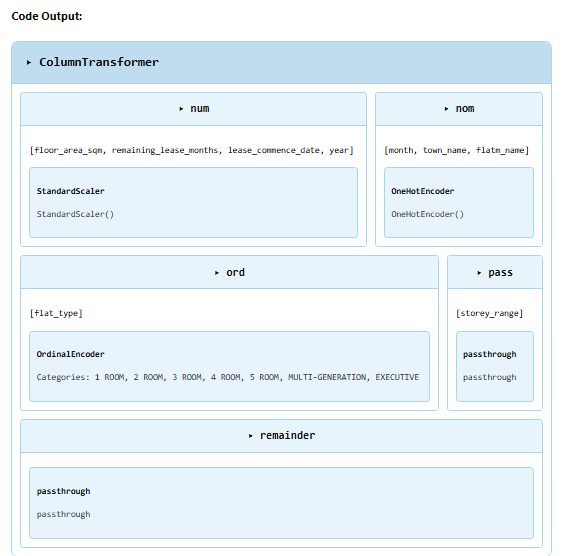

# MODEL DEVELOPMENT


### Simple Linear Regression
What is regresssion?
- is about relationships that helps us understand the quantify teh relationship between two or more variables by analysing this relationship we can make informed prediuction about one variable based on value of others. Regression seeks to predict a continous target Y in this case is predicting the housing prices which is a classical regressionb problem where the input data includes relevant information such as numbe rof rooms, location and floor.

1. Simple linear regression (Univariant Regression)
Starting point, simple linear regression deals with predicting a target variable using single input varuable such as drawing staight line thropugh set of point to best present their relationship. 

2. Multivariante Linear Regression
as we move beyound simple relationships, multivariante regression comes inti play. Here we predict a target variable using two or more input vairbal like adding more pieces to the puzzle making predicting work more detailed and accurate.

3. Other types of regression
There are several other types such as polynomical regsionn, lasso regression, ridge regression, regression trees, each suited to specific kinds of data and problems. 

### Simple Linear Regression
Imagine you are trying to predict your monthly electricity bill (Y) based on the number of hours you use your air conditioner (X). The more you use your air conditioner, the higher your bill will be. You have a scatter plot of data points representing the number of hours you use your air conditioner (X) and your electricity bill (Y). Simple linear regression finds the best straight line through these data points that represents this relationship. With that straight line, you can predict your bill every time you have the number of hours.

Simple linear regression, also known as univariate regression, is a method used to predict a target variable (Y) using a single input variable (X). The relationship between X and Y is modeled as a straight line., with the equation below:

Show Formula:
The simple linear regression equation is given by:


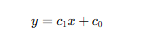

Where:

y is the predicted target variable.
x is the input variable.
c 1 is the slope of the line, representing how much y changes for a unit change in x.
c 0 is the y-intercept, the value of y when x is 0.
This formula represents a straight line that best fits the data, with c 1 and c 0 being the parameters that minimize the sum of the squared differences between the observed values and the predicted values.


With the equation defined above, let's translate that into our problem of predicting monthly electricity bill (Y) based on the number of hours you use your air conditioner (X).

In the simple linear regression equation, Y represents the predicted target variable, such as your electricity bill. The variable X is the input variable, which in this example is the number of hours you use your air conditioner. The coefficient c1 is the slope of the line, indicating how much your electricity bill increases for each additional hour of air conditioner usage. Lastly, c0 is the y-intercept, which represents the base cost of your electricity bill when no air conditioner is used.

At this point, you have the data points of the number of hours you used your air conditioner (X) and the corresponding monthly electricity bill (Y). But how do we know what are the values of coefficients c1 (slope) and c0 (y-intercept)? These coefficients determine how well-fit your straight line will be through the data points. This is where Ordinary Least Squares is helpful.

### Ordinary Least Squares
Imagine you are a detective trying to find the best path through a maze. You have several possible paths (data points) that show different ways to get through the maze. Your goal is to find the straightest and shortest path (best-fit line) that gets you from the start to the finish.

However, each path has some deviations (errors) where it doesn't follow a straight line exactly. To find the best path, you decide to measure how far each path deviates from the straight line. You want to minimise these deviations to get the most accurate straight path.

To do this, you calculate the square of each deviation (because squaring makes sure all deviations are positive and gives more weight to larger deviations), sum them up, and try to find the path that has the smallest total deviation. This is essentially what OLS does.

Ordinary least squares (OLS) is a method used in simple linear regression to find the best-fit line through a set of data points. The goal of OLS is to minimise the sum of the squared residuals (errors) between the observed values (actual data points) and the predicted values (points on the best-fit line). In this context, residual errors refer to the vertical differences between observed and predicted values.

ols new
How OLS Relates to Simple Linear Regression:

Simple Linear Regression: Simple linear regression aims to model the relationship between a single input variable X and a target variable Y . The model is represented by the equation Y = c1 X + c0 , where c1 is the slope and c0* is the y-intercept.

Finding the Best-Fit Line: To determine the best-fit line, we need to find the values of c1 and c0* that minimise the vertical differences between the actual values and the predicted values. OLS helps us achieve this by minimising the sum of the squared residuals (errors).

Sum of Squared Residuals: The residual (error) for each data point is the vertical difference between the actual value ( yi ) and the predicted value ( yi ). The squared residual for each data point is (yi - yi )2 . The sum of squared residuals for all data points is ∑(yi - yi )2 .

Minimisation: OLS minimises this sum of squared residuals to find the best-fit line. By solving the OLS optimisation problem, we get the values of c1 and c0* that result in the smallest possible sum of squared residuals. With that, the best-fit line is achieved.

### Multivariate Linear Regression

In our previous discussion, we looked at simple (univariate) linear regression, where we predicted the electricity bill based on a single variable—the number of hours the air conditioner was used. This approach works well when there's only one predictor. However, in most real-life situations, there are multiple factors that influence the outcome.

Imagine, in addition to air conditioner usage, we also have data on other appliances like the number of hours the washing machine, lights, and heater are used. We might want to know how all these factors together affect the electricity bill. 💲

Instead of fitting a separate simple linear regression model for each appliance, we can extend our analysis to incorporate all these variables into a single model. This is where multivariate linear regression comes in.

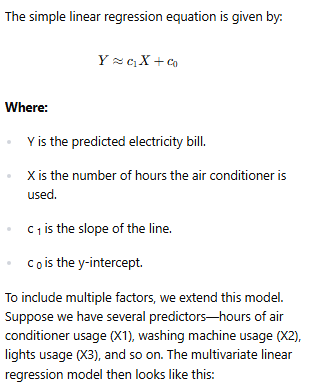

To include multiple factors, we extend this model. Suppose we have several predictors—hours of air conditioner usage (X1), washing machine usage (X2), lights usage (X3), and so on. The multivariate linear regression model then looks like this:

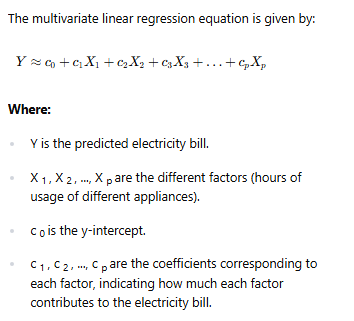

Each cj (coefficient) represents the average effect on Y (electricity bill) of a one-unit increase in Xj (each appliance usage), holding all other variables constant.

For example, if c1 is 5, it means that for each additional hour of air conditioner usage, the electricity bill increases by 5 units, assuming the usage of other appliances remains the same. Similarly, if c2 is 3, each extra hour of washing machine usage adds 3 units to the bill.



### Relating Back to HDB Resale Price Dataset 🏠
Let’s relate this to the HDB resale price dataset you were working on. In this dataset, you want to predict the resale price of an HDB flat. Instead of just looking at one factor, like the floor area, you have multiple factors that could influence the resale price, such as the location, remaining lease of the flat, number of rooms, and so on.

In this case, the multivariate linear regression model would look like this:

The multivariate linear regression equation for the HDB resale price dataset is given by:


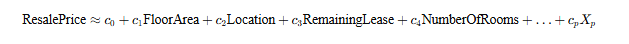

Where:

ResalePrice is the target variable we are trying to predict.

FloorArea, Location, RemainingLease, NumberOfRooms, ... are the predictors.

c 0 is the y-intercept.

c 1 , c 2 , c 3 , ... are the coefficients indicating how much each factor contributes to the resale price.

Each coefficient cj represents the average effect on the resale price of a one-unit increase in the corresponding predictor Xj , while holding all other variables constant.

For example:

c1* indicates how much the resale price increases with each additional square meter of floor area.

c2* reflects how the resale price varies depending on the location of the flat.

c3* shows the impact of the remaining lease of the flat on its resale price.

c4* indicates the effect of having more rooms on the resale price.

By using multivariate linear regression, you can better understand how all these factors together influence the resale price, providing a more comprehensive and accurate prediction model.
 



### Implementing Multivariate Linear Regression
Before we can implement multivariate linear regression, we need to integrate it with the ColumnTransformer preprocessor object we created in the previous section that performs all our data transformations. This ensures that all preprocessing steps are applied to the data before fitting the linear regression model. To achieve this, we will use the sklearn Pipeline, which allows us to chain multiple steps together.

The code below does the following:

Import Modules: Import Linear Regression model from Sklearn's linear models module.

Create the Pipeline: Create a pipeline that includes our preprocessor and the linear regression model. The preprocessor handles all data transformations, and the linear regression model is used for fitting and predicting the target variable.

In [41]:
from sklearn.linear_model import LinearRegression

# Create the pipeline with a linear regression model
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [42]:
lr_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('nom', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"n_jobs n_jobs: int, default=NoneNumber of j

Now, let's develop our first machine learning model by applying the data transformations and the linear regression model to our dataset. Notice how we use the newly created pipeline object to handle all these steps seamlessly. This approach allows us to efficiently preprocess the data and fit the model without having to manually apply each transformation separately.

The code below does the following:

Fit the Pipeline to the Training Data: We fit the entire pipeline to the training data. The pipeline consists of two main parts: the preprocessor and the regressor (Linear Regression model). The preprocessor performs all necessary data transformations, such as scaling numerical features and encoding categorical features. After the data is preprocessed, the Linear Regression model is fitted to the transformed training data. In other words, the Linear Regression model trains on the training data to learn the relationships between the input features (X_train) and the target variable (y_train).

Predict on the Validation Set:  We use the fitted pipeline to make predictions on the validation dataset (X_val). The preprocessor applies the same data transformations to the validation data as it did to the training data. The Linear Regression model then makes predictions based on the transformed validation data. The primary reason for using a validation set is to evaluate the model's performance. By predicting on the validation set, we can see how well our model generalises to new, unseen data.

In [43]:
print(X_train.columns.tolist())

['month', 'flat_type', 'storey_range', 'floor_area_sqm', 'lease_commence_date', 'town_name', 'flatm_name', 'year', 'remaining_lease_months']


In [44]:
# Fit the pipeline to the training data
lr_pipeline.fit(X_train, y_train)

# Predict on the validation set
y_val_pred = lr_pipeline.predict(X_val)

In [45]:
y_val_pred

array([365296.05722289, 466396.36567574, 320367.72593054, ...,
       591868.90472702, 320337.15324784, 735641.91745288], shape=(8446,))

## Model Evaluation

Now that you’ve trained your linear regression model on the training set and made predictions on the validation set, the next crucial step is to evaluate how well your model is performing. Model evaluation helps you understand the accuracy and reliability of your model, and identify areas for improvement. Among the commonly used metrics for regression problems are:

Mean Absolute Error (MAE)

Mean Squared Error (MSE)

Root Mean Squared Error (RMSE)

R-squared (Coefficient of Determination)

Let's delve into the details of Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and Coefficient of Determination ((R^{2})), comparing their mathematical definitions, advantages, disadvantages, use cases, and interpretations.

### Mean Absolute Error (MAE)
MAE measures the average magnitude of the errors in a set of predictions, without considering their direction.

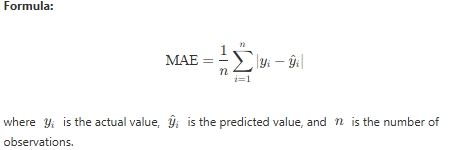

- Pros: Easy to understand and interpret, provides a linear score that directly corresponds to the average error in the predictions.

- Cons: Less sensitive to outliers compared to MSE.

- When to use: You want a straightforward measure of error magnitude without overly penalizing large errors. Suitable when dealing with outliers.

- How to interpret: A lower MAE indicates a better fit. The value represents the average magnitude of the errors in the predictions.

### Mean Squared Error (MSE)
MSE measures the average of the squared differences between the actual and predicted values.


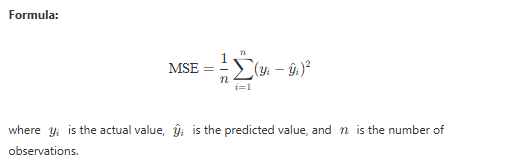


- Pros: Penalizes larger errors more than smaller ones, making it sensitive to outliers. For example, an error of 10 contributes 100 to the MSE, while an error of 1 contributes only 1.

- Cons: Can be hard to interpret due to the squaring of errors. The units of MSE are the square of the target variable's units, making it less intuitive.

- When to use: You need a strict penalization of large errors, and the model should prioritize reducing larger errors over smaller ones.

- How to interpret: A lower MSE indicates a better fit. Since MSE squares the errors, it gives more weight to larger errors, so a lower value means that the model makes fewer large errors.

### Root Mean Squared Error (RMSE)
RMSE is the square root of the Mean Squared Error.


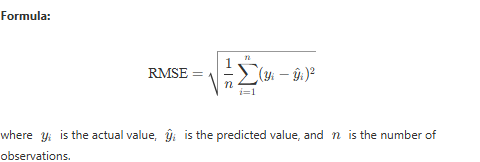


- Pros: More sensitive to outliers than MAE, making it useful when you want to penalize larger errors more severely. The units of RMSE are the same as the target variable, making it easier to interpret than MSE.

- Cons: Like MSE, the square root operation makes it slightly harder to interpret than MAE.

- When to use: You are concerned about large errors skewing the model performance and need a balance between error sensitivity and interpretability.

- How to interpret: A lower RMSE indicates a better fit. Since RMSE is in the same units as the target variable, it is easier to understand the typical magnitude of the errors.
### R-squared (Coefficient of Determination)

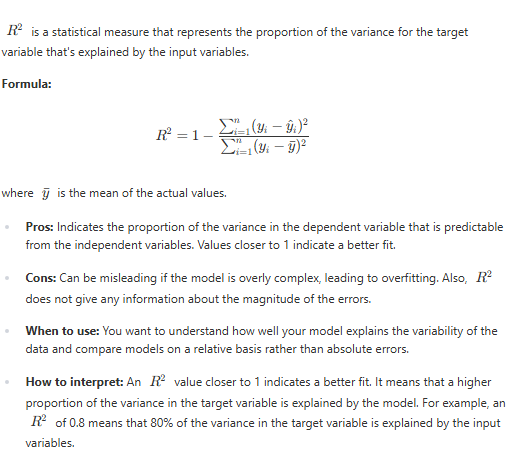

### Implementing Model Evaluation
After understanding the various metrics we can use to evaluate our linear regression model, let's implement the calculation. Scikit-learn (sklearn) provides these metrics ready to use, making it easy to evaluate the performance of your model.

The code below does the following:

Import the Necessary Metrics: Import the mean absolute error, mean squared error, root mean squared error, and R² score from sklearn’s metrics module.

Calculate Metrics: We calculate the regression metrics for the validation set based on the predictions made by the linear regression pipeline.

Display the Calculated Metrics: Print out the values of MAE, MSE, RMSE, and R² for the validation set, providing a clear understanding of the model’s performance.

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

# Calculate regression metrics for validation set
val_mae = mean_absolute_error(y_val, y_val_pred)
val_mse = mean_squared_error(y_val, y_val_pred)
val_rmse = root_mean_squared_error(y_val, y_val_pred)  # RMSE is the square root of MSE
val_r2 = r2_score(y_val, y_val_pred)

# Display the metrics
print(f"Validation MAE: {val_mae}")
print(f"Validation MSE: {val_mse}")
print(f"Validation RMSE: {val_rmse}")
print(f"Validation R2: {val_r2}")

Validation MAE: 42376.65731085122
Validation MSE: 3028318494.2235775
Validation RMSE: 55030.15986005835
Validation R2: 0.8584511292579838


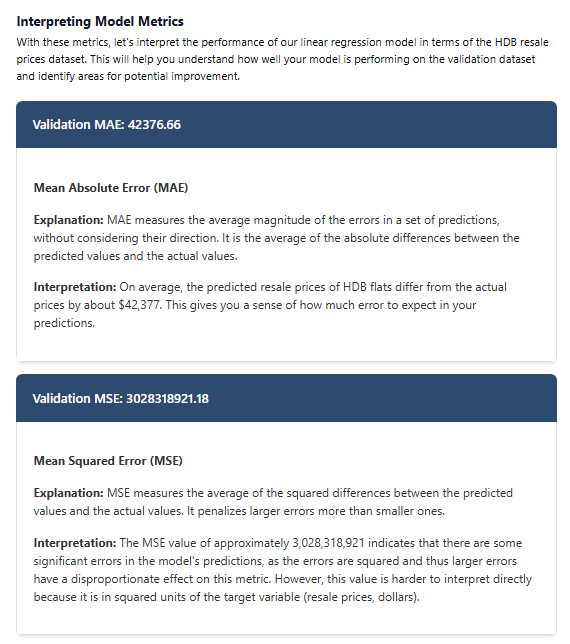

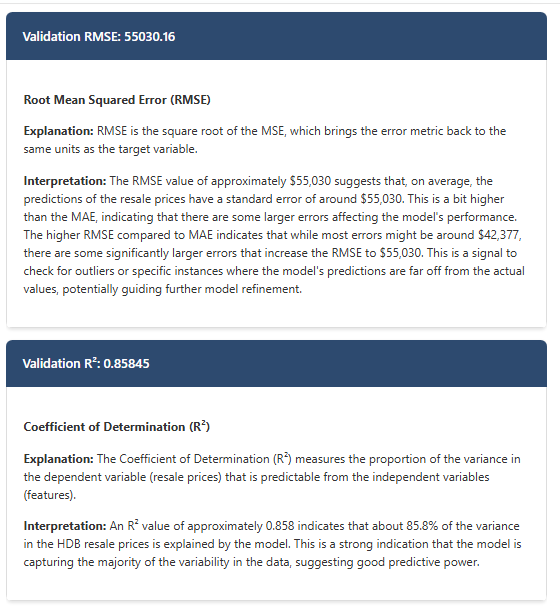

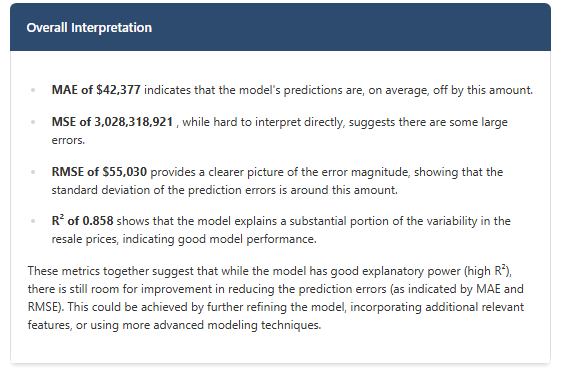

## Bias and Variance Tradeoff
As you continue your journey in machine learning, two important concepts you'll encounter are bias and variance. These concepts are crucial for understanding the performance and limitations of all your machine learning models, including the linear regression model you developed previously.

### Bias
Bias refers to the error introduced by approximating a real-world problem, which may be complex, by a simplified model.

High Bias: When a model has high bias, it means it is too simplistic and fails to capture the underlying patterns of the data. This often leads to underfitting.
Example: Using a linear model to fit data that follows a non-linear pattern.
Consequence: The model makes consistent errors on both the training and validation datasets.


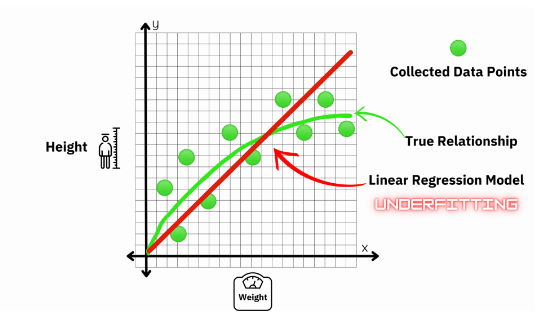

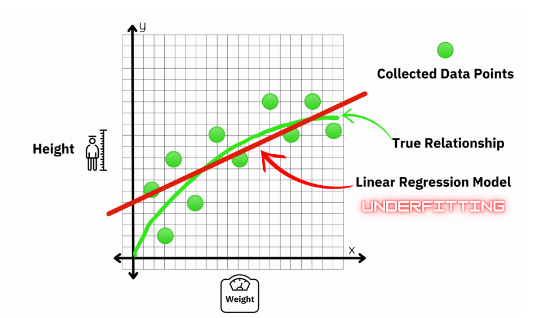


A model with high bias makes strong assumptions, which can simplify the relationships in the data too much. For example, linear regression assumes that the data has a linear relationship. If the true relationship in the data is not linear, such as a relationship between height and weight, the model will underfit. In the height and weight problem, assuming a linear relationship might not capture the true pattern where, for example, height increases with weight up to a certain point, but beyond that, the effect may plateau. This leads to poor performance because the model fails to capture the complexity of the data.


### Variance
Variance refers to the error introduced by the model's sensitivity to small fluctuations in the training data.

High Variance: When a model has high variance, it means it is too complex and captures the noise along with the underlying pattern. This often leads to overfitting.

Example: Using a very high-degree polynomial regression to fit data that has a linear pattern.

Consequence: The model performs well on the training dataset but poorly on the validation dataset due to its sensitivity to the noise in the training data.

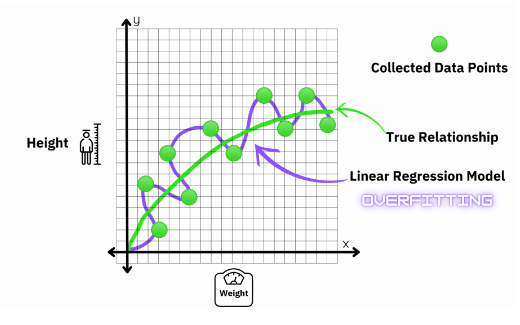

Variance measures how sensitive a model is to the specific training data it was trained on. It shows us how much the model's output changes when the training data is altered. High variance indicates that the model is overly dependent on the training data, causing it to overfit. This means that the model captures the noise in the training data, fitting every single data point perfectly. While this might seem ideal, in reality, such a model performs poorly on new, unseen data because it fails to generalise.

Models with high flexibility, such as complex polynomial regression and decision trees, tend to have high variance. Decision trees, for example, can split the data into very specific regions, capturing all nuances in the training data. Without constraints, they can become too complex and fail to perform well in the real world. If there are no limitations, a high variance model will grow and branch out to fit every single data point, leading to overfitting.

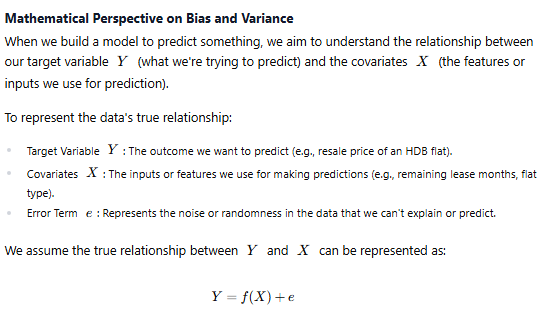


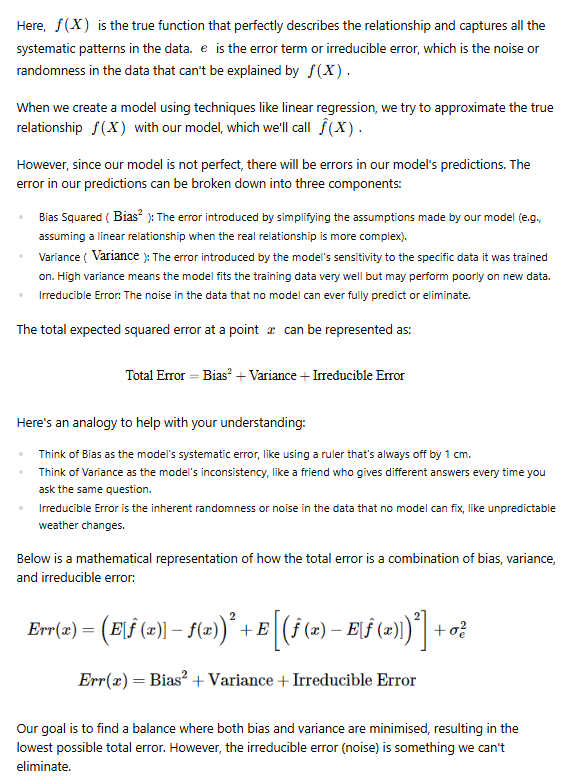

### Visualising Bias and Variance
The following target board below visually illustrates the concept of bias and variance. Successful hits on the center of this target board represents perfect model predictions, and the models that deviate from the center show increasing errors.

Underfitting: High bias and low variance. Occurs when a model cannot capture the underlying data pattern, often due to simplicity or insufficient data.
Overfitting: Low bias and high variance. Occurs when a model captures noise as if it were a genuine pattern, often in complex models like decision trees.

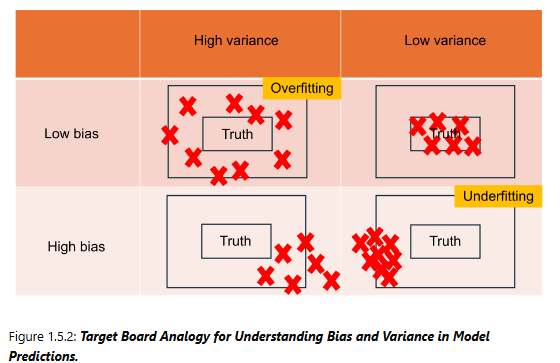

This diagram represents how deviations from the center of the target correlate with increased prediction errors in machine learning models. The center hit signifies perfect predictions, highlighting the goal of achieving a model that accurately captures the underlying data patterns without overfitting or underfitting. The concepts of underfitting (high bias and low variance) and overfitting (low bias and high variance) are visually demonstrated through their distance from the target center, emphasising the importance of model calibration in reducing overall error.


### Bias-Variance Tradeoff
The bias-variance tradeoff is the balance that machine learning practitioners strive to achieve to ensure a model that generalises well to new, unseen data.

The tradeoff exists because:

Reducing Bias Increases Variance: When we make our models more complex to better capture the true relationships in the data, we reduce bias. However, this also makes our model more sensitive to the noise in the training data, increasing variance.
Reducing Variance Increases Bias: When we simplify our models to make them less sensitive to the specific training data, we reduce variance. However, this also means that our model may not capture all the relevant patterns in the data, increasing bias.
The goal is to find a balance between bias and variance that minimises the total error. We aim to fit the data adequately to avoid underfitting while ensuring the model does not overfit the training data, thereby maintaining good performance and generalisability in real-world scenarios.


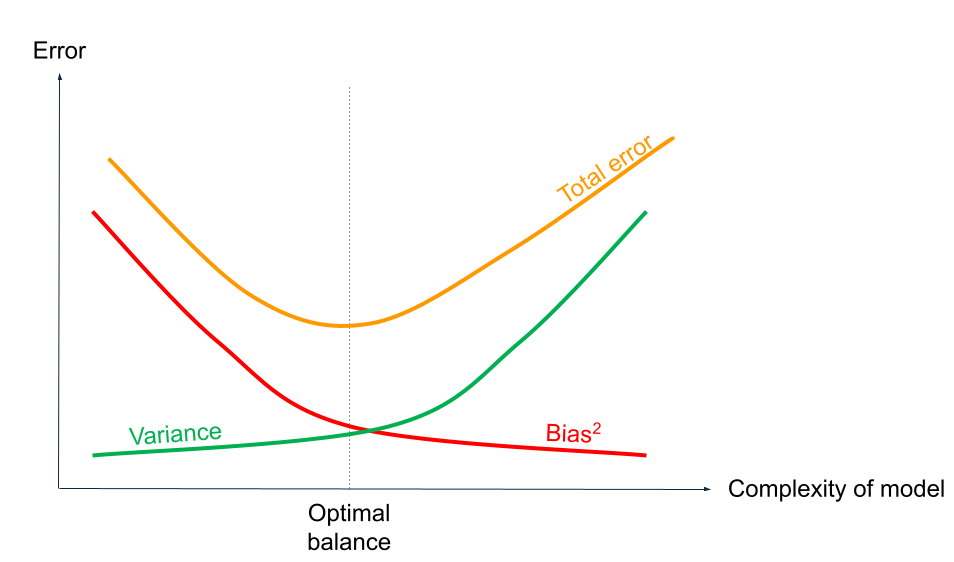


This figure depicts the delicate equilibrium that must be achieved between model simplicity (leading to high bias) and complexity (resulting in high variance) to minimise total error. It highlights the critical goal of developing a prediction model that neither overfits nor underfits, emphasising the significance of finding the optimal balance for creating accurate and reliable machine learning models.




## Ridge Regression
### Regularization for Linear Regression
In the world of machine learning, we often come across various techniques to build models that effectively capture the underlying patterns in our data. One straightforward approach is to use all available predictors (input variables) to fit a linear model. However, simply including every predictor can sometimes lead to models that don't perform well on new data because they overfit the training data.

An effective alternative is to apply regularization, a technique that shrinks some of the coefficient estimates towards 0. In this context, coefficient refers to the values that the algorithm learns from the training data to define the relationship between each predictor (input variable) and the target variable (output).

At first, it might not seem intuitive that restricting our model coefficients could lead to improvements. Yet, it's been found that this process of shrinking the coefficients can considerably reduce their variance (remember that high variance often leads to overfitted models), enhancing the model's ability to predict more accurately on unseen data.

Regularization introduces a penalty on the size of coefficients. Instead of allowing them to reach any value, it encourages smaller, more stable coefficients. This helps in several ways:

- Multicollinearity: When independent variables (predictors) are highly correlated, regularization can help by shrinking the coefficients of correlated predictors, reducing the model's sensitivity to these correlations.
- Model Complexity: Regularization reduces the complexity of the model by penalizing large coefficients, leading to simpler and more interpretable models.
- Overfitting Prevention: By penalizing large coefficients, regularization helps prevent the model from fitting the noise in the training data, ensuring better performance on new, unseen data.
- There are two common types of regularization techniques used in linear regression:
    - Ridge Regression (L2 Regularization)
    - Lasso Regression (L1 Regularization)

### Ridge Regression
Now that you have a solid understanding of bias and variance, it's time to explore a powerful technique called ridge regression, which helps in balancing these concepts to improve model performance.

Ridge regression is a type of linear regression that includes a regularization term to prevent overfitting. Ridge regression is an extension of the traditional ordinary least squares fitting procedure, which you might recall is used to estimate coefficients ( \left(c_{0}, c_{1}, ..., c_{p} \right) ) by minimizing the residual sum of squares (RSS) or sum of squared residuals. Ridge regression modifies the OLS approach slightly by adding a penalty to the size of the coefficients. This penalty is known as the shrinkage penalty and shrinks the model coefficients towards 0. In other words, the reduction of coefficient size caused by the shrinkage penalty translates to each predictor feature having less influence on the final prediction.

The coefficients in ridge regression are found by minimizing the following cost function:

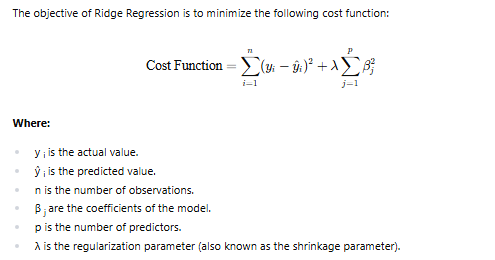

Ridge regression is a powerful tool to control overfitting by penalizing large coefficients, helping to achieve a better bias-variance tradeoff. By adding a regularization term, ridge regression makes your model more robust and better at generalizing to new data. Ridge regression helps in finding the optimal bias-variance tradeoff by:

- Reduced Model Complexity:
Large coefficients indicate a strong influence of certain features on the predictions. By shrinking these coefficients, ridge regression reduces the overall complexity of the model. This helps in preventing the model from capturing noise in the training data, which can lead to overfitting.
- Improved Generalization:
By penalizing large coefficients, ridge regression discourages the model from fitting the training data too closely. This regularization ensures that the model can generalize better to new, unseen data. In other words, the model becomes more robust and performs better on validation or test datasets.
- Multicollinearity Management:
In datasets where predictor variables are highly correlated (multicollinearity), the estimates of the coefficients can become unstable and exhibit high variance. Ridge regression addresses this issue by adding a penalty to the size of the coefficients, which stabilizes their estimates and reduces variance.
- Bias-Variance Tradeoff:
Forcing the coefficients to be smaller with the regularization term introduces some bias into the model, as the true relationship might require larger coefficients for accurate representation. However, this bias is often a worthwhile tradeoff because it significantly reduces variance. The overall effect is a better balance between bias and variance, leading to improved model performance.

### Implementing Ridge Regression
In the HDB resale price dataset you've been working on, implementing a ridge regression model can help us assess if there's an improvement in our predictive metrics and identify which coefficients are more significant.

When predicting the value of a resale flat, it's intuitive that different input features will have varying levels of influence on the price. For example, the location of the flat or the number of rooms are likely to have a higher impact on the price compared to the month of listing. Ridge regression helps address this by shrinking the coefficients of less important features, thereby enhancing the model's ability to generalize to unseen data.

Remember that by applying ridge regression, we add a regularization term to our linear model, which penalizes large coefficients and prevents overfitting. This not only improves the robustness of our model but also provides us with insights into the relative importance of each feature.

Let's implement ridge regression on our HDB resale price dataset, then evaluate its performance against the baseline linear regression model you developed previously.

The code below does the following:

- Import Modules: Import Ridge Regression model from Sklearn's linear models module.
- Create the Pipeline: Create a ridge pipeline that includes our preprocessor and the ridge regression model. The preprocessor handles all data transformations, and the ridge regression model is used for fitting and predicting the target variable. Observe that the ridge regression model is instantiated with an alpha of 1, which controls the amount of regularization applied. This is the default alpha and should be adjusted with hyperparameter tuning (you will learn about this later) to find the optimal alpha. In Sklearn's ridge regression, alpha is equivalent to lambda in the regularization term.
- Fit the Pipeline to the Training Data: We fit the entire pipeline to the training data. The preprocessor performs all necessary data transformations and the ridge regression model trains on the training data.
- Predict on the Validation Set: We use the fitted ridge pipeline to make predictions on the validation dataset (X_val). Observe that the predictions are stored in the variable  'y_val_pred_ridge'.
- Calculate Metrics: We calculate the regression metrics for the validation set based on the predictions made by the ridge regression pipeline.
- Display the Calculated Metrics: Print out the values of MAE, MSE, RMSE, and R² for the validation set, providing a clear understanding of the ridge regression model’s performance.


In [48]:
from sklearn.linear_model import Ridge

# Fit Ridge Regression with lambda (alpha in scikit-learn)
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1))
])
ridge_pipeline.fit(X_train, y_train)

# Predict on the validation set with Ridge Regression
y_val_pred_ridge = ridge_pipeline.predict(X_val)

# Calculate regression metrics for validation set with Ridge Regression
val_mae_ridge = mean_absolute_error(y_val, y_val_pred_ridge)
val_mse_ridge = mean_squared_error(y_val, y_val_pred_ridge)
val_rmse_ridge = root_mean_squared_error(y_val, y_val_pred_ridge)  # RMSE is the square root of MSE
val_r2_ridge = r2_score(y_val, y_val_pred_ridge)

# Display the metrics for Ridge Regression
print("Ridge Regression Metrics:")
print(f"Ridge Validation MAE: {val_mae_ridge}")
print(f"Ridge Validation MSE: {val_mse_ridge}")
print(f"Ridge Validation RMSE: {val_rmse_ridge}")
print(f"Ridge Validation R²: {val_r2_ridge}")

Ridge Regression Metrics:
Ridge Validation MAE: 42375.64413065402
Ridge Validation MSE: 3027465264.691389
Ridge Validation RMSE: 55022.406932915874
Ridge Validation R²: 0.8584910106895424


Comparing Metrics
Now that we've computed the metrics for both ridge regression and linear regression, let's compare them to understand the differences and what they mean for our model's performance.

|Metric	Ridge| Regression|	Linear Regression|
| :--- | :---: | :---: |
|Validation MAE|	42376.00678812924|	42376.65759306324|
|Validation MSE|	3027468676.6665053|	3028318921.178535|
|Validation RMSE|	55022.43793823121|	55030.163739339674|
|Validation R²|	0.8584908512078941|	0.8584511093013669|

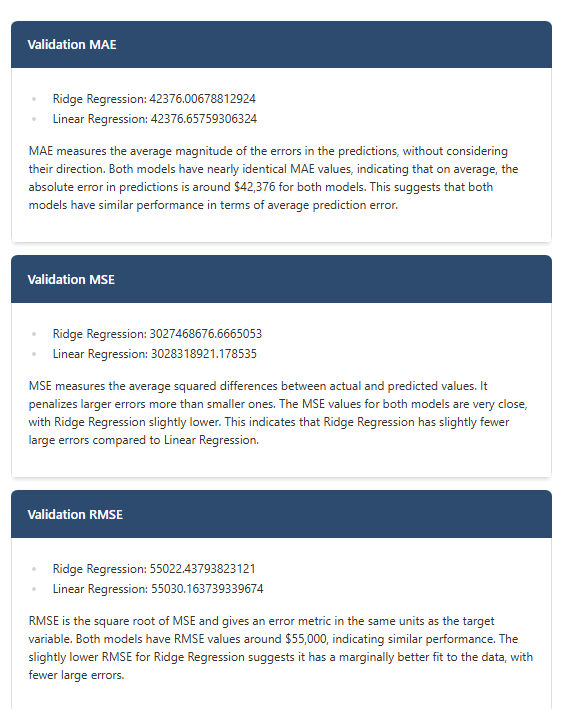

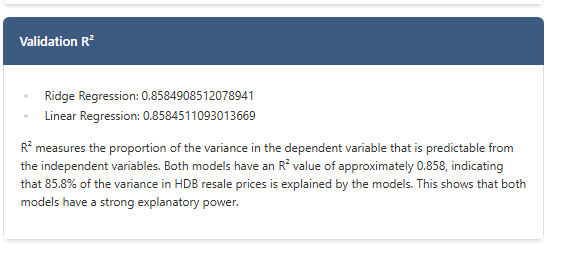


The metrics for ridge regression and linear regression are very similar, which might suggest that the data doesn't have severe multicollinearity issues or that the regularization effect of ridge regression with the default alpha=1 is minimal. However, the slight improvements in MSE and RMSE for ridge regression indicate that it has marginally better performance in reducing larger errors and overfitting.

By applying ridge regression, you ensure that the model coefficients do not become excessively large, leading to better stability and generalization to unseen data. Even though the improvements are slight in this case, regularization is a crucial technique for enhancing model robustness, especially in more complex datasets with potential multicollinearity issues.

### Comparing Coefficients
Now that we have evaluated the performance metrics of both linear regression and ridge regression models, let's dive deeper into the coefficients of these models. The coefficients indicate the influence of each feature on the target variable, which in our case is the resale price of HDB flats. **By comparing the coefficients, we can see how regularization (ridge regression) affects the importance assigned to each feature.**

The code below does the following:

Extract Coefficients: Extract the coefficients from the linear and ridge regression models by accessing the 'regressor' step in their respective pipelines.
Extract Feature Names: Extracts and combines the names of numerical, one-hot encoded nominal, ordinal, and passthrough features into a single list called 'feature_names'.
Create and Reshape Coefficients DataFrame: Creates a DataFrame 'coef_df' with columns for features and their corresponding coefficients from both models. Then, convert the DataFrame to a long format suitable for plotting with Seaborn. This format has a column for feature names, model type (Linear or Ridge), and coefficient values.
Plot the Coefficients: Use Seaborn's barplot function to create a bar plot comparing the coefficients of linear regression and ridge regression for each feature.





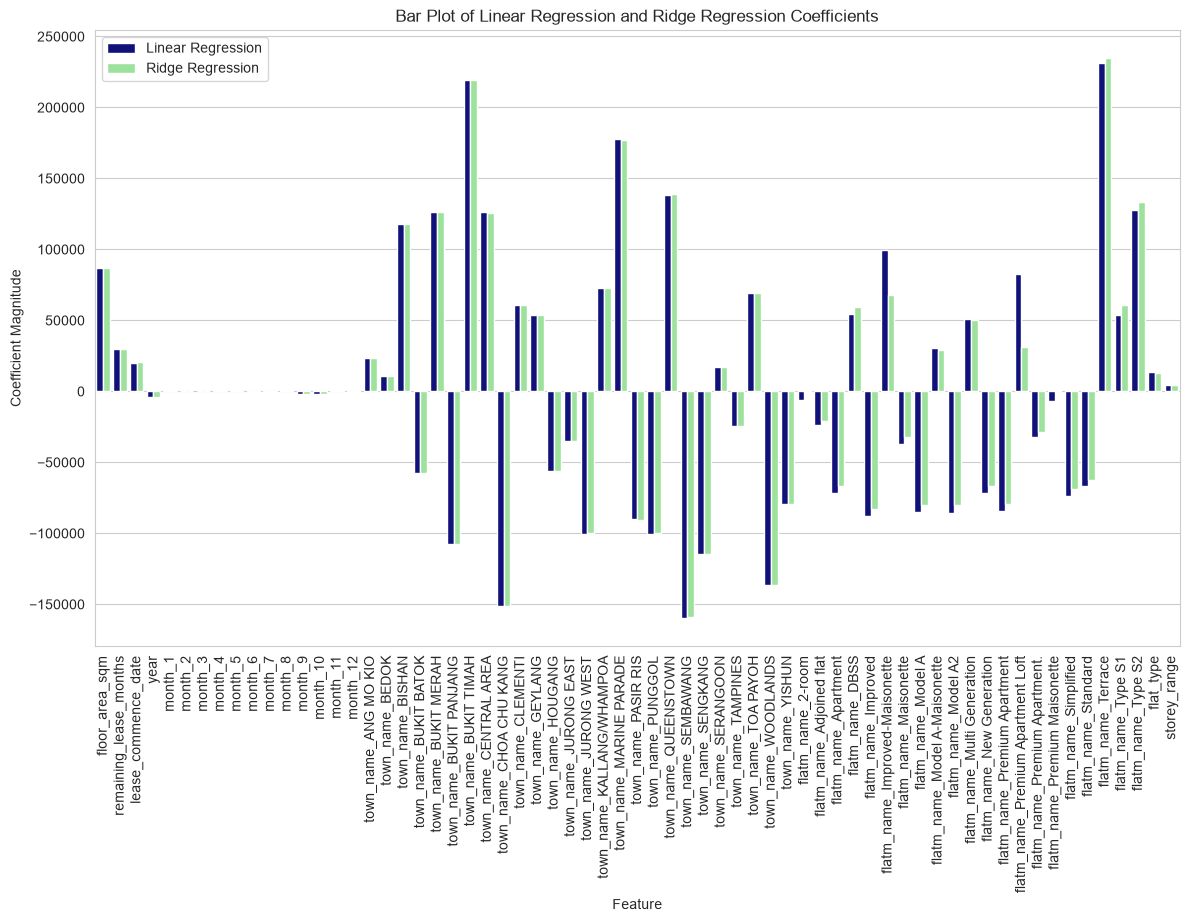

In [50]:
# Extract the coefficients of the linear regression model
lr_coefs = lr_pipeline.named_steps['regressor'].coef_

# Extract the coefficients of the ridge regression model
ridge_coefs = ridge_pipeline.named_steps['regressor'].coef_

# Assuming feature_names contains the names of the features after preprocessing
feature_names = (
    numerical_features +
    list(ridge_pipeline.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot'].get_feature_names_out(nominal_features)) +
    ordinal_features +
    passthrough_features
)

# Create a DataFrame for plotting
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Linear Regression': lr_coefs,
    'Ridge Regression': ridge_coefs
})

# Melt the DataFrame to long format for seaborn
coef_df = coef_df.melt(id_vars='Feature', var_name='Model', value_name='Coefficient')

# Plotting the coefficients with seaborn
plt.figure(figsize=(14, 8))
sns.barplot(data=coef_df, x='Feature', y='Coefficient', hue='Model', palette=['darkblue', 'lightgreen'])

plt.xlabel('Feature')
plt.ylabel('Coefficient Magnitude')
plt.title('Bar Plot of Linear Regression and Ridge Regression Coefficients')
plt.xticks(rotation=90)
plt.grid(True, axis='y')
plt.legend(loc='upper left')
plt.show()

Now that we've visualized the coefficients for both linear regression and ridge regression models, it's time to interpret the plot and understand the impact of these coefficients on predicting the HDB resale prices. Here, we'll focus on a few key features to illustrate how the coefficients influence the predictions and how ridge regression helps in regularization.

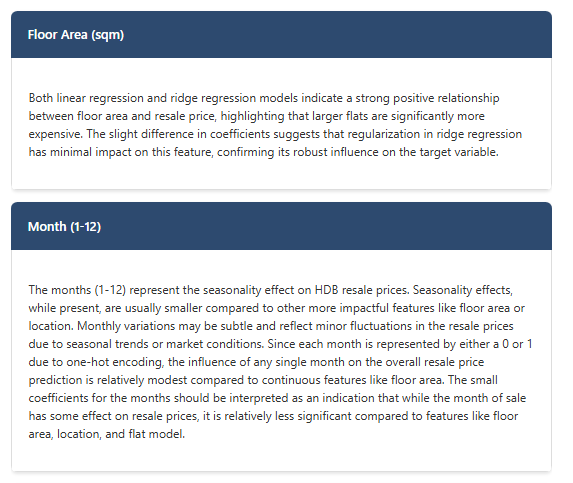

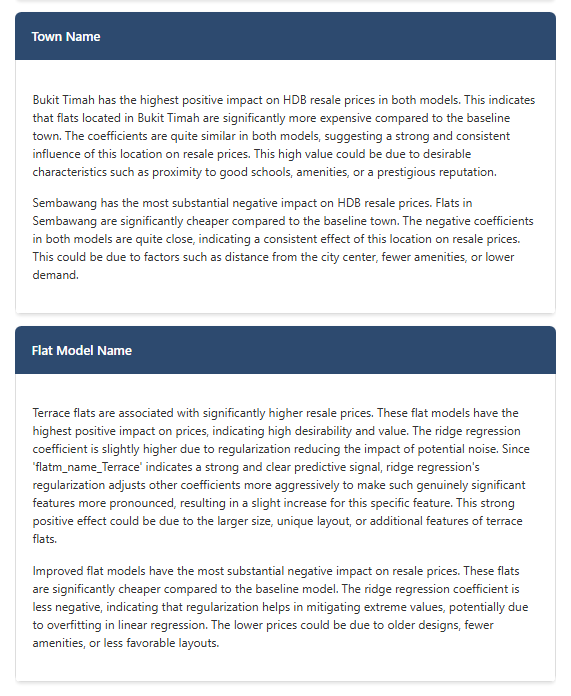

## Lasso Regression
Now that you have a solid understanding of ridge regression, let's explore another powerful technique called lasso regression, which also helps in improving model performance by balancing bias and variance.

Lasso regression, like ridge regression, is a type of linear regression that includes a regularization term to prevent overfitting. However, lasso regression (which stands for Least Absolute Shrinkage and Selection Operator) modifies the traditional ordinary least squares fitting procedure by adding a penalty to the sum of the absolute values of the coefficients. This penalty not only shrinks the coefficients towards 0 but can also force some coefficients to be exactly 0, effectively performing built-in feature selection by excluding irrelevant features from the model.

The coefficients in lasso regression are found by minimizing the following cost function:

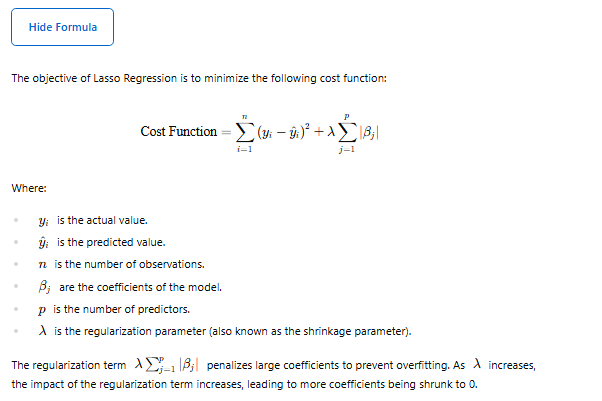

Lasso regression is a powerful tool to control overfitting by penalizing large coefficients and performing feature selection, helping to achieve a better bias-variance tradeoff. By adding a regularization term, lasso regression makes your model more robust and better at generalizing to new data. Lasso regression helps in finding the optimal bias-variance tradeoff by:

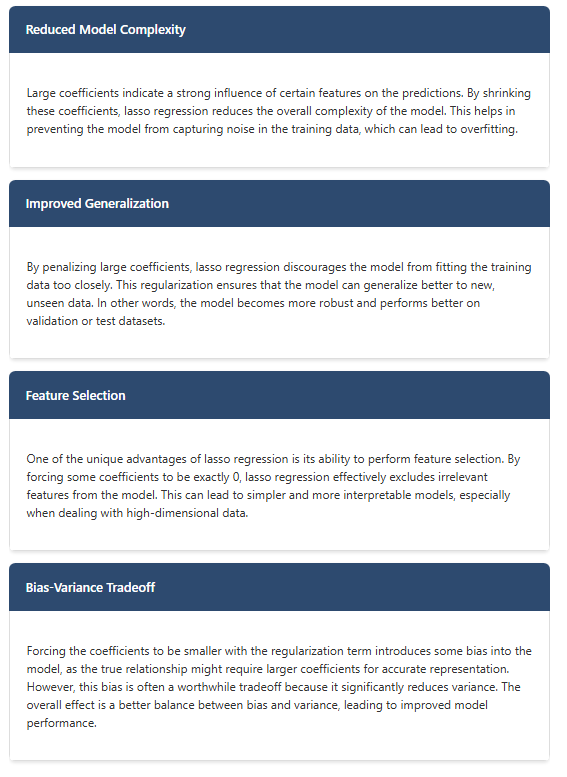


### Implementing Lasso Regression
In the HDB resale price dataset you've been working on, implementing a lasso regression model can help us assess if there's an improvement in our predictive metrics and identify which coefficients are more significant. Lasso regression has a unique ability to force some coefficients to be exactly 0 if they are insignificant, effectively performing feature selection.

Remember that by applying lasso regression, we add a regularization term to our linear model, which penalizes large coefficients and prevents overfitting. This not only improves the robustness of our model but also provides us with insights into the relative importance of each feature.

Let's implement lasso regression on our HDB resale price dataset, then evaluate its performance against the baseline linear regression model you developed previously.

The code below does the following:

Import Modules: Import Lasso Regression model from Sklearn's linear models module.
Create the Pipeline: Create a lasso pipeline that includes our preprocessor and the lasso regression model. The preprocessor handles all data transformations, and the lasso regression model is used for fitting and predicting the target variable. Observe that the lasso regression model is instantiated with an alpha of 1, which controls the amount of regularization applied. This is the default alpha and should be adjusted with hyperparameter tuning (you will learn about this later) to find the optimal alpha. In Sklearn's lasso regression, alpha is equivalent to lambda in the regularization term.
Fit the Pipeline to the Training Data: We fit the entire pipeline to the training data. The preprocessor performs all necessary data transformations and the lasso regression model trains on the training data.
Predict on the Validation Set: We use the fitted lasso pipeline to make predictions on the validation dataset (X_val). Observe that the predictions are stored in the variable 'y_val_pred_lasso'.
Calculate Metrics: We calculate the regression metrics for the validation set based on the predictions made by the lasso regression pipeline.
Display the Calculated Metrics: Print out the values of MAE, MSE, RMSE, and R² for the validation set, providing a clear understanding of the lasso regression model’s performance.

In [51]:
from sklearn.linear_model import Lasso

# Fit Lasso Regression with default alpha
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Lasso(alpha=1))
])
lasso_pipeline.fit(X_train, y_train)

# Predict on the validation set with Lasso Regression
y_val_pred_lasso = lasso_pipeline.predict(X_val)

# Calculate regression metrics for validation set with Lasso Regression
val_mae_lasso = mean_absolute_error(y_val, y_val_pred_lasso)
val_mse_lasso = mean_squared_error(y_val, y_val_pred_lasso)
val_rmse_lasso = root_mean_squared_error(y_val, y_val_pred_lasso)  # RMSE is the square root of MSE
val_r2_lasso = r2_score(y_val, y_val_pred_lasso)

# Display the metrics for Lasso Regression
print("Lasso Regression Metrics:")
print(f"Lasso Validation MAE: {val_mae_lasso}")
print(f"Lasso Validation MSE: {val_mse_lasso}")
print(f"Lasso Validation RMSE: {val_rmse_lasso}")
print(f"Lasso Validation R²: {val_r2_lasso}")

c:\Users\User\miniconda3\envs\hdbenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:786: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.148691e+13, tolerance: 1.457e+11
  model = cd_fast.sparse_enet_coordinate_descent(


Lasso Regression Metrics:
Lasso Validation MAE: 42376.35265988858
Lasso Validation MSE: 3028079185.1785846
Lasso Validation RMSE: 55027.98547265368
Lasso Validation R²: 0.8584623149787531


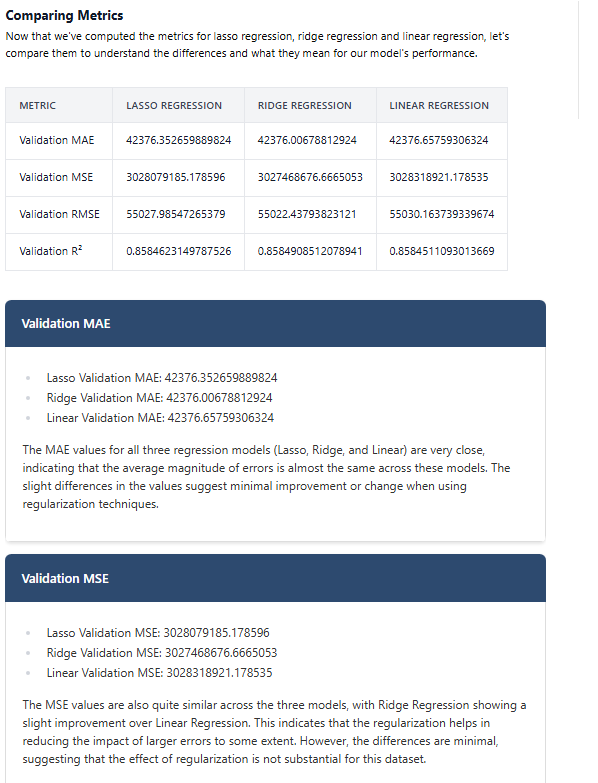
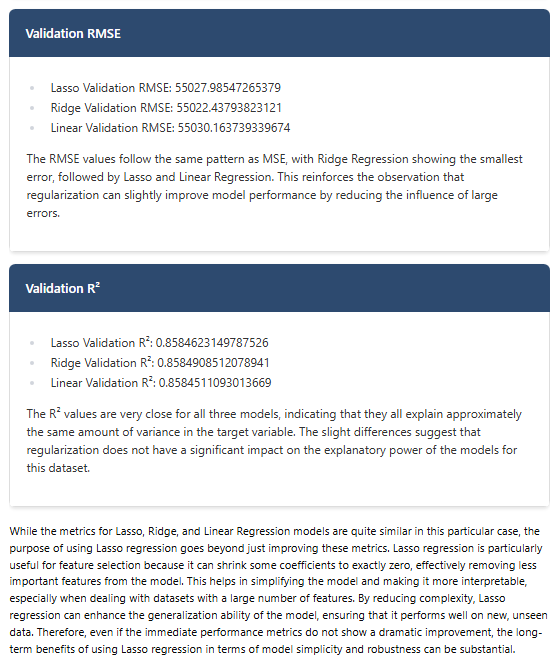

### Comparing Coefficients
Understanding the differences in the coefficients of linear regression and lasso regression is important for interpreting the model and the significance of the features. By comparing the coefficients of these models, we can gain insights into how each regression technique handles feature selection and regularization.

Remember, linear regression assumes no regularization and tries to minimize the residual sum of squares to find the best fit line. In contrast, lasso regression adds a regularization term to the cost function, which can shrink some coefficients to zero. This feature makes lasso useful for feature selection, as it can effectively remove less important features from the model.

The code below does the following:

Extract Coefficients: Extract the coefficients from the linear and lasso regression models by accessing the 'regressor' step in their respective pipelines.
Extract Feature Names: Extracts and combines the names of numerical, one-hot encoded nominal, ordinal, and passthrough features into a single list called 'feature_names'.
Create and Reshape Coefficients DataFrame: Creates a DataFrame 'coef_df' with columns for features and their corresponding coefficients from both models. Then, convert the DataFrame to a long format suitable for plotting with Seaborn. This format has a column for feature names, model type (Linear or Lasso), and coefficient values.
Plot the Coefficients: Use Seaborn's barplot function to create a bar plot comparing the coefficients of linear regression and lasso regression for each feature.

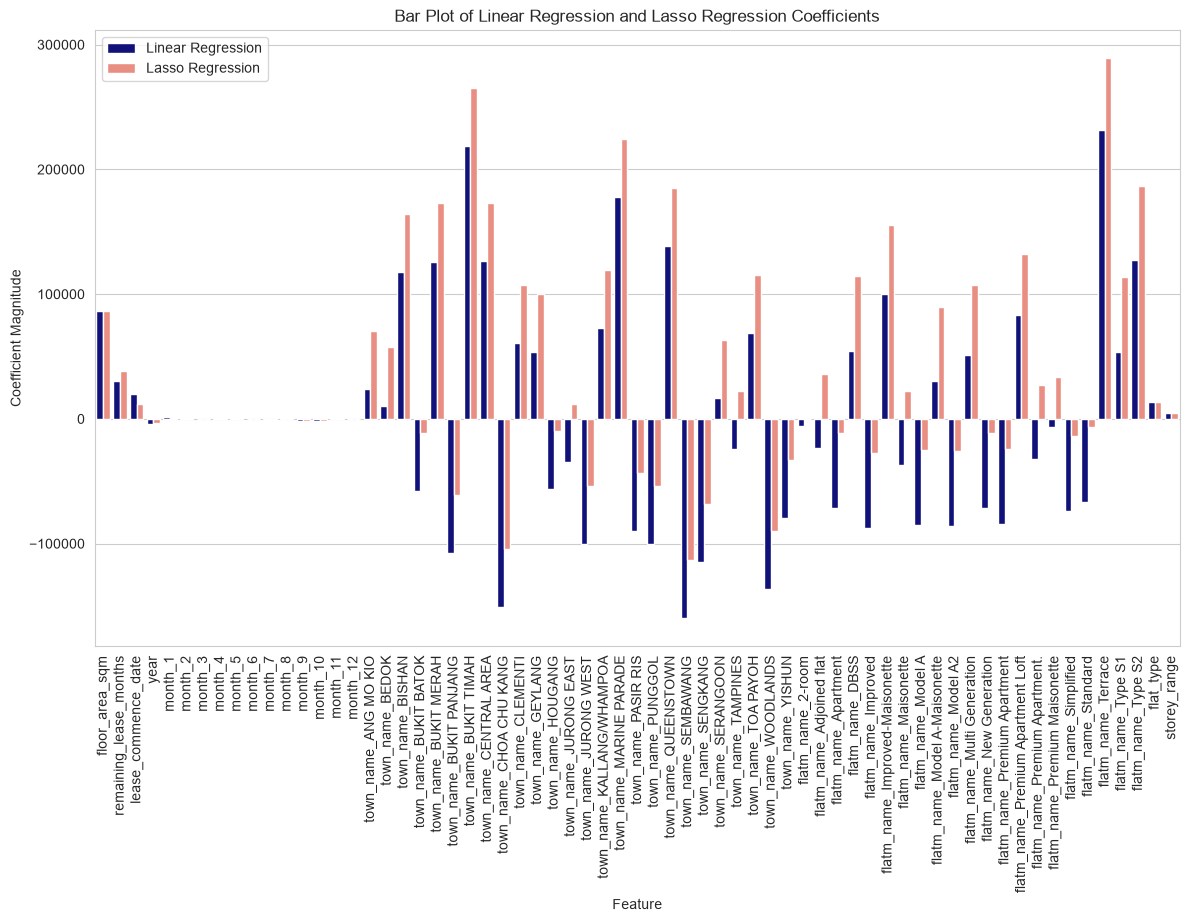

In [52]:
# Extract the coefficients of the linear and lasso regression models
lr_coefs = lr_pipeline.named_steps['regressor'].coef_
lasso_coefs = lasso_pipeline.named_steps['regressor'].coef_

# Extract feature names after preprocessing
feature_names = (
    numerical_features +
    list(preprocessor.transformers_[1][1].named_steps['onehot'].get_feature_names_out(nominal_features)) +
    ordinal_features +
    passthrough_features
)

# Create a DataFrame for plotting
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Linear Regression': lr_coefs,
    'Lasso Regression': lasso_coefs
})

# Melt the DataFrame to long format for seaborn
coef_df = coef_df.melt(id_vars='Feature', var_name='Model', value_name='Coefficient')

# Plotting the coefficients with seaborn
plt.figure(figsize=(14, 8))
sns.barplot(data=coef_df, x='Feature', y='Coefficient', hue='Model', palette=['darkblue', 'salmon'])

plt.xlabel('Feature')
plt.ylabel('Coefficient Magnitude')
plt.title('Bar Plot of Linear Regression and Lasso Regression Coefficients')
plt.xticks(rotation=90)
plt.grid(True, axis='y')
plt.legend(loc='upper left')
plt.show()

Now that we've visualized the coefficients for both linear regression and lasso regression models, let's interpret the plot above. We'll focus on a few key features for analysis.

Similar to linear regression, Bukit Timah continues to have the highest positive impact on HDB resale prices, with an even more pronounced effect in lasso regression. This consistency underscores the strong influence of location on resale prices. Conversely, Sembawang maintains the highest negative impact, though this impact is less pronounced in lasso regression, illustrating the regularization effect that lasso introduces.

Terrace flats have an even higher positive impact in lasso regression, further indicating their strong influence on resale prices. The impact of Improved flats is reduced in lasso regression, showing that regularization has shrunk the negative influence of this feature.

Lasso regression has identified certain features as insignificant, effectively removing them from the model. For instance, the effect of selling in March is considered insignificant, leading to its coefficient being shrunk to exactly 0. Similarly, the impact of 2-room flats is also deemed insignificant and removed from the model.

Several coefficients have changed from negative to positive between linear and lasso regression. This change is a result of the regularization process in lasso, which seeks to find a more balanced or stable solution by adjusting the direction of some relationships to minimize the overall cost function.

For example:

The coefficients for Jurong East and Tampines changed from negative to positive, suggesting a different interpretation of their impact on resale prices when regularization is applied.
The coefficients for adjoined flats, maisonettes, premium apartments, and premium maisonettes also changed from negative to positive, reflecting a different assessment under regularization.
These changes highlight how lasso regression can provide a different perspective on the importance and direction of various features, leading to a more robust and generalized model.



# HYPERPARAMETER TUNING


### Hyperparameter Tuning 🛠️
In machine learning, creating a model that performs well on unseen data is the ultimate goal. While cleaning the data and selecting the right algorithm are important steps, there's another vital aspect that significantly influences the performance of your model: hyperparameter tuning.

Hyperparameters are the parameters set by you before the learning (training) process begins. Unlike model parameters, which are learned during training (such as weights in a neural network), hyperparameters are external configurations that influence the training process and the structure of the model.

Imagine you're a chef trying to create the perfect dish. The ingredients you use (e.g., meat, vegetables, spices) are like the data features in a machine learning model. The hyperparameters are like the cooking settings—temperature, cooking time, and the amount of each spice.

Just like adjusting the temperature or cooking time can make the dish more delicious or completely ruin it, tuning hyperparameters can significantly improve or degrade the performance of your machine learning model. The right combination of these settings helps you create a dish (or model) that is perfectly balanced and appeals to the taste (or performs well on unseen data).

Examples of hyperparameters include:
- The regularization parameter (𝛼) in Ridge and Lasso regression.
- The number of trees in a Random Forest.
- The learning rate in gradient descent.

### Grid Search CV
Imagine you're still that chef, and you want to find the best combination of spices for your dish. Grid Search Cross-Validation (Grid Search CV) is like systematically trying every possible combination of spices from a predefined set. You might try a combination with 1 teaspoon of salt, 2 teaspoons of pepper, and 1 teaspoon of paprika, then another with 2 teaspoons of salt, 1 teaspoon of pepper, and 1.5 teaspoons of paprika, and so on.

Grid Search CV is a hyperparameter optimisation technique used to tune model parameters to achieve the best possible performance. It involves an exhaustive search over a specified parameter grid, testing every possible combination of hyperparameter values and evaluating each combination using cross-validation. Cross-validation is a resampling procedure used to evaluate model performance by splitting the dataset into multiple subsets (folds). The most common form is k-fold cross-validation, where the data is divided into k subsets, and the model is trained on k-1 subsets and tested on the remaining subset. This process is repeated k times, each time using a different subset as the test set. The chosen performance metric is averaged across all k folds to get a more reliable estimate of model performance.

The process for Grid Search CV is exhaustive and ensures you find the best combination, but it can be time-consuming and resource-intensive, especially if you have many spices (hyperparameters) and a large number of possible combinations.

Let's further break down the process using our chef analogy:
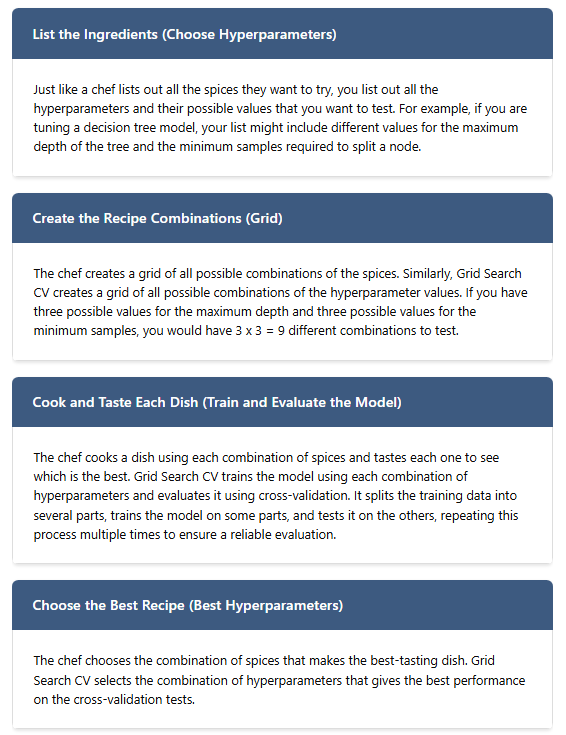


### Implementing Grid Search CV
Now that you have a solid understanding of Grid Search CV, let's apply this technique to the HDB resale price dataset using the ridge and lasso regression models you have developed previously. Hyperparameter tuning using Grid Search CV will help us find the optimal parameters for these models, potentially improving their predictive performance. We'll specify a range of values for 'alpha' (regularization strength) and 'fit_intercept' for both ridge and lasso regression models. If you ever wondered how big or small of an alpha to set in the previous section, this is where we systematically explore different values.

The code below does the following:

Import Modules: Import GridSearchCV from sklearn.model_selection.

Define Hyperparameter Grid: Define a dictionary 'param_grid'. 'regressor__alpha' specifies a list of possible values for the alpha parameter (which controls the regularization strength) that we want to test. 'regressor__fit_intercept' specifies whether to calculate the intercept for this model. If set to False, no intercept will be used in calculations. Take note of the double underscore syntax.

Create Pipelines: Create 2 pipelines, 'ridge_pipeline' for ridge regression and 'lasso_pipeline' for lasso regression. This is similar to the pipelines we created previously.

Perform Grid Search CV: Perform Grid Search with cross-validation for both ridge and lasso regression. 'ridge_grid_search' and 'lasso_grid_search' are instances of GridSearchCV that take the respective pipelines, the parameter grid, and the cross-validation strategy (cv=5 means 5-fold cross-validation). The scoring='r2' parameter indicates that the R² score will be used to evaluate the performance of the models. Fit the instances of GridSearchCV on the training data.

In [53]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'regressor__alpha': [0.1, 1, 10, 100, 1000],
    'regressor__fit_intercept': [True, False]
}

# Create the pipeline with a ridge regression model
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

# Create the pipeline with a lasso regression model
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Lasso())
])

# Perform grid search with cross-validation for Ridge regression
ridge_grid_search = GridSearchCV(ridge_pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)
ridge_grid_search.fit(X_train, y_train)

# Perform grid search with cross-validation for Lasso regression
lasso_grid_search = GridSearchCV(lasso_pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)
lasso_grid_search.fit(X_train, y_train)

c:\Users\User\miniconda3\envs\hdbenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:786: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.738150e+13, tolerance: 1.457e+11
  model = cd_fast.sparse_enet_coordinate_descent(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...r', Lasso())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'regressor__alpha': [0.1, 1, ...], 'regressor__fit_intercept': [True, False]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbo

In [54]:
# Print the best parameters found by grid search for Ridge regression
print("Best Ridge parameters:", ridge_grid_search.best_params_)

# Print the best parameters found by grid search for Lasso regression
print("Best Lasso parameters:", lasso_grid_search.best_params_)

Best Ridge parameters: {'regressor__alpha': 0.1, 'regressor__fit_intercept': True}
Best Lasso parameters: {'regressor__alpha': 0.1, 'regressor__fit_intercept': True}


After determining the best hyperparameter combinations for our ridge and lasso regression models, it's time to evaluate these tuned models. Remember, we should still be evaluating the tuned models on our validation dataset. This will help us understand how well these optimised models perform compared to our initial models with default parameters.

The code below does the following:

Evaluate the Best Ridge Model: 'ridge_grid_search.best_estimator' retrieves the ridge regression model with the best hyperparameters from the grid search, then uses it to make predictions on the validation set. The MAE, MSE, RMSE, and R² metrics are calculated then displayed.

Evaluate the Best Lasso Model: 'lasso_grid_search.best_estimator' retrieves the lasso regression model with the best hyperparameters from the grid search, then uses it to make predictions on the validation set. The MAE, MSE, RMSE, and R² metrics are calculated then displayed.

In [ ]:
# Evaluate the best Ridge model on the validation set
best_ridge_model = ridge_grid_search.best_estimator_
y_val_pred_ridge = best_ridge_model.predict(X_val)

# Calculate regression metrics for validation set for Ridge
val_mae_ridge = mean_absolute_error(y_val, y_val_pred_ridge)
val_mse_ridge = mean_squared_error(y_val, y_val_pred_ridge)
val_rmse_ridge = root_mean_squared_error(y_val, y_val_pred_ridge)  # RMSE is the square root of MSE
val_r2_ridge = r2_score(y_val, y_val_pred_ridge)

print("Best Ridge Regression Metrics:")
print(f"Ridge Validation MAE: {val_mae_ridge}")
print(f"Ridge Validation MSE: {val_mse_ridge}")
print(f"Ridge Validation RMSE: {val_rmse_ridge}")
print(f"Ridge Validation R²: {val_r2_ridge}")

# Evaluate the best Lasso model on the validation set
best_lasso_model = lasso_grid_search.best_estimator_
y_val_pred_lasso = best_lasso_model.predict(X_val)

# Calculate regression metrics for validation set for Lasso
val_mae_lasso = mean_absolute_error(y_val, y_val_pred_lasso)
val_mse_lasso = mean_squared_error(y_val, y_val_pred_lasso)
val_rmse_lasso = root_mean_squared_error(y_val, y_val_pred_lasso)  # RMSE is the square root of MSE
val_r2_lasso = r2_score(y_val, y_val_pred_lasso)

print("Best Lasso Regression Metrics:")
print(f"Lasso Validation MAE: {val_mae_lasso}")
print(f"Lasso Validation MSE: {val_mse_lasso}")
print(f"Lasso Validation RMSE: {val_rmse_lasso}")  
print(f"Lasso Validation R²: {val_r2_lasso}")

Now that we have run the Grid Search CV and found the best hyperparameters for both ridge and lasso regression models, it's time to evaluate their performance. In the table below, we have the validation metrics for the best-tuned ridge and lasso models, as well as their default configurations and the default multivariate linear regression model.

By comparing these metrics across the different models, we can see how tuning the hyperparameters has affected the performance of ridge and lasso regression. We are particularly interested in whether the tuned models perform better than their default counterparts and the default multivariate linear regression model.

Take a moment to review the table and consider which model provides the best balance between error metrics and explanatory power (R²). This will give you insights into how well the model might perform on unseen data and whether the hyperparameter tuning process has improved model performance.


| Model | MAE | MSE | RMSE | R² |
| :--- | :---: | :---: | :---: | :---: |
| **Best Ridge Regression** *(Tuned $\alpha=0.1$)* | 42,374.5043 | 3,027,107,697.3566 | 55,019.1575 | 0.8585 |
| **Ridge Regression** *(Default $\alpha=1$)* | 42,376.0068 | 3,027,468,676.6665 | 55,022.4379 | 0.8585 |
| **Best Lasso Regression** *(Tuned $\alpha=0.1$)* | 42,377.2472 | 3,028,324,908.9034 | 55,030.2181 | 0.8585 |
| **Lasso Regression** *(Default $\alpha=1$)* | 42,376.3527 | 3,028,079,185.1786 | 55,027.9855 | 0.8585 |
| **Default Linear Regression** | 42,376.6576 | 3,028,318,921.1785 | 55,030.1637 | 0.8585 |

After evaluating the metrics, it is evident that the best ridge regression model with tuned hyperparameters of alpha=0.1 performs the best overall. It has the lowest MAE, MSE, and RMSE, and the highest R², indicating it provides the most accurate predictions and explains the most variance in the HDB resale prices.

Therefore, the best ridge regression model will be the chosen model for predicting HDB resale prices. This model offers a good balance of low error rates and high explanatory power, making it the most reliable choice for our task.


## Randomized Search CV
Randomized Search CV
Imagine you're a bit more adventurous with your cooking. Instead of trying every possible combination of spices, you decide to randomly pick different combinations. You might randomly choose to try 2 teaspoons of salt, 0.5 teaspoons of pepper, and 2 teaspoons of paprika, then another combination with 1 teaspoon of salt, 1.5 teaspoons of pepper, and 0.5 teaspoons of paprika.

Randomized Search Cross-Validation (Randomized Search CV) works similarly. Instead of exhaustively searching through all possible combinations, it randomly selects combinations to try. This approach is often more efficient, as it allows you to cover a wide range of possibilities without testing every single one, and it can be surprisingly effective in finding good combinations quickly. Instead of defining a fixed set of values for each hyperparameter, you define a distribution from which values are randomly sampled. The algorithm randomly picks combinations of hyperparameters from these distributions. For each randomly selected combination, cross-validation is performed to evaluate the model performance. The combination that yields the best performance on the validation set is selected.

Randomized Search CV can identify effective hyperparameter combinations more quickly than Grid Search CV because it does not require evaluating every possible combination. By randomly sampling combinations, it reduces the computational burden and speeds up the search process. This approach is more scalable to higher-dimensional hyperparameter spaces, making it particularly suitable for complex models with numerous hyperparameters. It efficiently explores the hyperparameter space without the exhaustive computations required by Grid Search CV. By specifying distributions for hyperparameters, you can provide a more flexible and comprehensive exploration of the hyperparameter space. This flexibility enables a more thorough search, potentially uncovering better-performing hyperparameter settings.

### Implementing Random Search CV
We will now implement Randomized Search CV on our HDB resale prices dataset. Let's use the same pipelines and hyperparameters as before but with Randomized Search CV to find the best parameters for both ridge and lasso regression models.

The code below does the following:

Import Modules: Import RandomizedSearchCV from sklearn.model_selection.
Define Parameter Grid: Specify the same hyperparameters and their possible values as before. With Randomized Search CV, you have the option to specify distributions. For example, you may set 'regressor__alpha': uniform(loc=0.1, scale=9.9). The 'uniform' distribution from the 'scipy.stats' library generates random numbers that are uniformly distributed over 0.1 to 10.0, allowing you to sample a wide range of alpha values. We are not using it in the code, but you are encouraged to experiment with it.
Create Pipelines: Create two separate pipelines, one for ridge regression and one for lasso regression.
Perform Randomized Search with Cross-Validation: RandomizedSearchCV is used to perform hyperparameter tuning. n_iter=10 specifies that 10 different combinations of the hyperparameters should be randomly sampled and tested. The parameter grid defines 5 values for 'alpha' and 2 values for 'fit_intercept', resulting in a total of 5×2=10 possible combinations. Since n_iter=10, RandomizedSearchCV will evaluate all of the 10 different combinations of the hyperparameters, randomly selecting from the defined parameter grid. In cases where the parameter grid has more than 10 possible combinations, RandomizedSearchCV will randomly select only 10 combinations to test, as specified by the 'n_iter' parameter.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter distributions for hyperparameter tuning
param_grid = {
    'regressor__alpha': [0.1, 1, 10, 100, 1000],
    'regressor__fit_intercept': [True, False]
}

# Create the pipeline with a ridge regression model
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

# Create the pipeline with a lasso regression model
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Lasso())
])

# Perform randomized search with cross-validation for Ridge regression
ridge_random_search = RandomizedSearchCV(ridge_pipeline, param_distributions=param_grid, n_iter=10, cv=5, scoring='r2', random_state=42, n_jobs=-1)
ridge_random_search.fit(X_train, y_train)

# Perform randomized search with cross-validation for Lasso regression
lasso_random_search = RandomizedSearchCV(lasso_pipeline, param_distributions=param_grid, n_iter=10, cv=5, scoring='r2', random_state=42, n_jobs=-1)
lasso_random_search.fit(X_train, y_train)

c:\Users\User\miniconda3\envs\hdbenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:786: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.738150e+13, tolerance: 1.457e+11
  model = cd_fast.sparse_enet_coordinate_descent(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...r', Lasso())])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'regressor__alpha': [0.1, 1, ...], 'regressor__fit_intercept': [True, False]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_inde

Now that we have performed the randomized search cross-validation on our ridge and lasso regression models, it's time to see which hyperparameters were chosen as the best. The random search has evaluated multiple combinations of hyperparameters to find the ones that yield the best performance. In scenarios where the parameter space is much larger, you will notice that Randomized Search CV is significantly faster than Grid Search CV due to its selective sampling approach. Let's take a look at the results.

In [56]:
# Print the best parameters found by random search for Ridge regression
print("Best Ridge parameters:", ridge_random_search.best_params_)

# Print the best parameters found by random search for Lasso regression
print("Best Lasso parameters:", lasso_random_search.best_params_)

Best Ridge parameters: {'regressor__fit_intercept': True, 'regressor__alpha': 0.1}
Best Lasso parameters: {'regressor__fit_intercept': True, 'regressor__alpha': 0.1}


You may notice that the best parameters found by Randomized Search CV are the same as those identified in the Grid Search CV we performed earlier, with alpha=0.1 still being the best. A word of caution, though: while Randomized Search CV is faster, it does not always guarantee the optimal solution, although it can come close. The effectiveness of Randomized Search CV highly depends on the tradeoff you are willing to make between search efficiency and the comprehensiveness of the search space coverage.

Since the best parameters identified by Randomized Search CV are the same as those we found using Grid Search CV, the resulting model performance metrics will also be identical. Therefore, we will not display the results again. This reinforces the understanding that Randomized Search CV can indeed find optimal or near-optimal solutions in a more efficient manner, but in this instance, it has confirmed our Grid Search CV results. Let's proceed to the next section.

### Final Model Evaluation
Great job on tuning the hyperparameters and selecting the best models for ridge and lasso regression! Now, it's time to move forward and make predictions on the test set using these optimised models.

The test set is the final portion of dataset aside during the data splitting phase. It has remained separate from the training and validation sets throughout the entire modeling process. This separation ensures that our final model is evaluated on completely unseen data, providing an unbiased and accurate estimate of its performance.

Here's why saving the test set for last is important:

- Unbiased Evaluation: By not exposing the test set during the model training and hyperparameter tuning phases, we ensure that our final evaluation metrics reflect how the model performs on new, unseen data. This helps us gauge the true generalisation capability of our model. It's the ultimate measure of how well our model will perform in practice.

- Avoiding Overfitting: If we were to use the test set during training or tuning, we risk overfitting our model to the specifics of the test data. This would lead to overly optimistic performance estimates that wouldn't hold up in real-world scenarios.

### Implementing Final Model Evaluation
After an extensive process of exploratory data analysis, data cleaning and preprocessing, model development, and hyperparameter tuning, we have identified that the ridge regression model with the best hyperparameters performs the best compared to lasso regression and multivariate linear regression. It's time to evaluate the final model on the test set to see how well it performs on completely unseen data.

Remember, the test set has been kept separate from the training and validation sets throughout the entire process to ensure that our final model evaluation is unbiased. This step is vital as it provides an accurate estimate of the model's performance in a real-world scenario.

The code for evaluating the model on the test set is similar to what we have done before, with the only new addition being the prediction on the test set. Below is the code to perform the final evaluation using the best ridge regression model found from our Grid Search CV.

In [57]:
# Best model from Ridge regression (Grid Search)
best_ridge_model = ridge_grid_search.best_estimator_

# Predict on the test set with Ridge Regression
y_test_pred_ridge = best_ridge_model.predict(X_test)

# Calculate regression metrics for the test set for Ridge
test_mae_ridge = mean_absolute_error(y_test, y_test_pred_ridge)
test_mse_ridge = mean_squared_error(y_test, y_test_pred_ridge)
test_rmse_ridge = root_mean_squared_error(y_test, y_test_pred_ridge)
test_r2_ridge = r2_score(y_test, y_test_pred_ridge)

print("Best Ridge Regression Model, Final Test Metrics:")
print(f"Final Test MAE: {test_mae_ridge}")
print(f"Final Test MSE: {test_mse_ridge}")
print(f"Final Test RMSE: {test_rmse_ridge}")
print(f"Final Test R²: {test_r2_ridge}")

Best Ridge Regression Model, Final Test Metrics:
Final Test MAE: 41272.73074735997
Final Test MSE: 2896767079.2512374
Final Test RMSE: 53821.62278537537
Final Test R²: 0.865634248217164


Congratulations on all your hard work! The model's performance on the test set is slightly better than on the validation set across all metrics (MAE, MSE, RMSE, and R²). This suggests that our ridge regression model generalises well to new, unseen data and is robust and reliable for predicting HDB resale prices. The lower error metrics and higher R² on the test set indicate that the model is well-tuned and capable of making accurate predictions. 🥳



# Developing an End-to-End Machine Learning Pipeline🏭
So far, we have been working in our eda.ipynb Jupyter notebook. While Jupyter notebooks are great for initial data exploration and prototyping, they are usually not used in real-world production environments for several reasons.

Firstly, notebooks are not ideal for handling large-scale data processing tasks or for deployment in production environments, making them less scalable. Secondly, tracking changes and maintaining version control is more challenging in notebooks compared to script-based code, making it difficult to manage code evolution effectively. Additionally, collaborating on notebooks can be cumbersome, especially when multiple people need to work on the same codebase, which can lead to conflicts and inefficiencies. Finally, ensuring reproducibility of results can be harder with notebooks due to hidden state and cell execution order issues, making it difficult to recreate the exact sequence of steps that led to a particular result. These challenges highlight the importance of transitioning from notebooks to a more robust, script-based approach for production environments.

Instead, it is best practice to package your code into a script-based end-to-end machine learning pipeline. The goal of the pipeline is to streamline and automate the entire machine learning workflow, ensuring that each step, from data cleaning to final predictions, is performed consistently and efficiently. This helps in creating a robust, reproducible, and scalable process that can be easily maintained, shared with team members, and deployed into production environments.

To create a comprehensive end-to-end machine learning pipeline, you will be learning about a few different components that make this possible:

📂 Project Repository Structure: Organising your project files and directories in a clear and logical manner.

🧩 Designing Modular Code: Breaking down your code into reusable functions, classes, and scripts.

⚙️ Creating a Configuration File: Centralising your project's settings and parameters in a single configuration file.

📦 Managing Dependencies: Using tools like pip or conda to manage and document the required packages for your project.

📄 Crafting a README: Writing a clear and informative README file to explain your project, how to set it up, and how to use it.

By structuring your project in this way, you ensure that your code is maintainable, scalable, and ready for production deployment. Let's dive into each of these components and learn how to transition from Jupyter notebooks to a robust, production-ready pipeline. Move on to the next section when you're ready.



### Project Repository Structure 📂
A well-structured project repository is essential for maintainability, clarity, and organisation. When a repository is organised logically, it becomes easier to navigate, allowing yourself and other team members to quickly find the files they need. This reduces the time spent searching for specific pieces of code or documentation and helps new team members get up to speed more efficiently.

Maintaining a clear structure in your repository also ensures that the project remains manageable as it grows. By keeping related files together and separating different types of content (such as code, data, and documentation), you can prevent the repository from becoming cluttered and confusing. This separation of concerns makes it easier to update, debug, and extend the project, ensuring that each part of the system can be worked on independently without causing disruptions to other parts.

You may have observed that the template code repository you downloaded previously looks very similar to the tree structure you see below. Every item in the tree structure contributes to the end-to-end machine learning pipeline. Hover over the individual items to learn more!

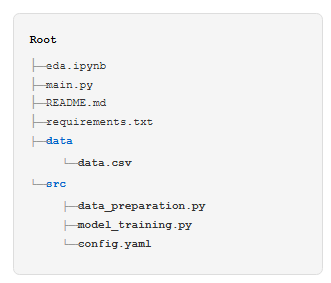


### Coding Exercise 💻
Now it's your turn to ensure that your project repository is well-organised and that all files and folders are correctly placed. This exercise will help you verify the structure and plan for the contents of your current project repository. Follow the instructions below:

1. Verify File and Folder Locations

Open your current project repository and check that all files and folders are in their correct locations as per the structure provided above. Make sure that directories like  data  and  src  are present and that they contain the appropriate files, even if they are currently empty.
2. Plan Code Placement

Think about the code you have worked on thus far. Plan where each piece of code would go in this project repository structure. For example, code for data cleaning would go in  data_preparation.py  within the  src  folder.
3. Organise and Reflect

If any files or folders are missing or incorrectly placed, organise them appropriately. Take a moment to reflect on the organisation of your project. Is it intuitive and easy to navigate? Can someone new to the project understand the structure and purpose of each file and folder?



### Designing Modular Code 🧩
In this section, we will learn about the principles of modular code design with a focus on creating a production-ready end-to-end machine learning pipeline. Modular code refers to breaking down your code into smaller, manageable, and reusable components, which are typically functions and classes. This approach enhances maintainability, reusability, readability, and testability of your code. By structuring your code into distinct modules, you can easily extend, test and debug individual parts, making the development process more efficient and organised.

There are a few steps we will take to design modular code for our end-to-end pipeline. They are:

1. Extracting code from Jupyter notebook

2. Defining functions and classes

3. Separating code into scripts

We have already covered the basics of developing code for exploratory data analysis, data cleaning and preprocessing, model development, hyperparameter tuning, and final model prediction in previous sections. Now, we will take a step further and refactor this code into well-defined functions and classes. We will also organise these components into separate scripts, such as data_preparation.py, model_training.py, and main.py, following best software engineering practices. This structure is essential for developing scalable and maintainable machine learning pipelines suitable for production environments.



### xtracting Code from Jupyter Notebook
When transitioning to a production-ready pipeline, we typically do not include the exploratory data analysis (EDA) code. This is because EDA relies heavily on interactive exploration, where the AI practitioner can quickly visualise data distributions, relationships, and outliers. The process involves many trial-and-error steps, visualisations, and ad-hoc calculations, which are less relevant for a structured production pipeline. Additionally, EDA often involves a non-linear workflow, where the AI practitioner jumps back and forth between different steps based on insights gained along the way. This exploratory nature is different from the linear and structured nature of a production pipeline. Including EDA code can clutter the repository and make the core pipeline harder to follow, so it’s best to keep EDA in separate Jupyter notebooks for clarity and focus.

For the production pipeline, we focus on components that ensure repeatability and scalability. These include code for data cleaning, data preprocessing and transformation, model development, hyperparameter tuning, and final model prediction. Focusing on these components creates a robust, maintainable, and scalable machine learning pipeline that is ready for production deployment.

Let's start extracting the relevant code from your eda.ipynb Jupyter notebook. Go through your eda.ipynb from top to bottom, selecting the components related to data cleaning, preprocessing, model development, hyperparameter tuning, and final model prediction. Then, verify your selections against the prepared examples below.

```
# Extracted Code for Data Cleaning, Preprocessing and Transformations
import re
import pandas as pd

# read from csv
df = pd.read_csv('resale_transactions.csv')

df.drop_duplicates(inplace=True)

# Replace 'FOUR ROOM' with '4 ROOM' in the 'flat_type' column
df['flat_type'].replace('FOUR ROOM', '4 ROOM', inplace=True)

df['lease_commence_date'] = df['lease_commence_date'].abs()

# Function to convert storey_range to ordinal scale by taking the average of the range
def convert_storey_range(storey_range: str) -> float:
    """
    Converts a storey range string into its average numerical value.
    
    The function takes a storey range in the format 'XX TO YY', splits it into two parts,
    converts these parts to integers, and returns the average of these integers.
    
    Args:
        storey_range (str): A string representing a range of storeys, in the format 'XX TO YY'.
        
    Returns:
        float: The average value of the two storeys in the range.
        
    Example:
        convert_storey_range('07 TO 09') -> 8.0
    """
    range_values = storey_range.split(' TO ')
    return (int(range_values[0]) + int(range_values[1])) / 2

# Use the .apply() method to convert the 'storey_range' column with the function
df['storey_range'] = df['storey_range'].apply(convert_storey_range)

def fill_missing_names(df: pd.DataFrame, id_column: str, name_column: str) -> pd.DataFrame:
    """
    Fills missing values in the 'name_column' using the 'id_column'.

    Args:
        df (pd.DataFrame): The DataFrame containing the columns to be filled.
        id_column (str): The name of the column containing the IDs.
        name_column (str): The name of the column containing the names to be filled.

    Returns:
        pd.DataFrame: The DataFrame with missing values in 'name_column' filled.
    """
    # Identify missing values in the 'name_column'
    missing_names = df[name_column].isna()

    # Create a dictionary mapping 'id_column' to 'name_column'
    name_mapping = df[[id_column, name_column]].dropna().drop_duplicates().set_index(id_column)[name_column].to_dict()

    # Fill missing 'name_column' using the mapping
    df.loc[missing_names, name_column] = df.loc[missing_names, id_column].map(name_mapping)

    return df

# Fill missing values in 'town_name' column
df = fill_missing_names(df=df, id_column='town_id', name_column='town_name')

# Fill missing values in 'flatm_name' column
df = fill_missing_names(df=df, id_column='flatm_id', name_column='flatm_name')

# Drop irrelevant features
df = df.drop(columns=['id', 'town_id', 'flatm_id'])

# Convert 'month' column to datetime
df['year_month'] = pd.to_datetime(df['month'], format='%Y-%m')

# Extract year and month from the datetime object
df['year'] = df['year_month'].dt.year
df['month'] = df['year_month'].dt.month

# drop year_month
df = df.drop(columns=['year_month'])

def extract_lease_info(lease_str: str) -> int:
    """
    Convert lease information from a string format to total months.

    This function takes a string representing the remaining lease period, which
    may include years and months in various formats (e.g., "70 years 3 months",
    "85 years", "67"), and converts it to the total number of months.

    Args:
        lease_str (str): The remaining lease period as a string.

    Returns:
        int: The total number of months, or None if the input is NaN.
    """

    if pd.isna(lease_str):
        return None
    
    # Regular expression to extract years and months
    years_match = re.search(r'(\d+)\s*years?', lease_str)
    months_match = re.search(r'(\d+)\s*months?', lease_str)
    number_match = re.match(r'^\d+$', lease_str.strip())
    
    if years_match:
        years = int(years_match.group(1))
    elif number_match:  # If only a number is present, assume it's in years
        years = int(number_match.group(0))
    else:
        years = 0
        
    months = int(months_match.group(1)) if months_match else 0
    
    # Convert the total lease period to months
    total_months = years * 12 + months
    return total_months

# Extract lease information
df['remaining_lease_months'] = df['remaining_lease'].apply(extract_lease_info)

# Drop the 'remaining_lease' column
df = df.drop(columns=['remaining_lease'])

# Drop the 'block' and 'street_name' columns
df = df.drop(columns=['block', 'street_name'])

# Separate the data into features and target
X = df.drop(columns='resale_price')
y = df['resale_price']

from sklearn.model_selection import train_test_split

# Split the data into training (80%) and test-validation (20%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)

# Split the test-validation set (20%) into validation (10%) and test (10%) sets
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Define numerical features to be standardized
numerical_features = ['floor_area_sqm', 'remaining_lease_months', 'lease_commence_date', 'year']

# Create a numerical transformer pipeline
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# Define nomial features to be one-hot encoded
nominal_features = ['month', 'town_name', 'flatm_name']

# Define ordinal features to be ordinally encoded
ordinal_features = ['flat_type']

# Define the ordinal categories for flat_type
flat_type_categories = ['1 ROOM', '2 ROOM', '3 ROOM', '4 ROOM', '5 ROOM', 'MULTI-GENERATION', 'EXECUTIVE']

# Define passthrough features that will not be transformed
passthrough_features = ['storey_range']

# Create a nominal transformer pipeline
nominal_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='error'))
])

# Create an ordinal transformer pipeline
ordinal_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(categories=[flat_type_categories], handle_unknown='error'))
])

from sklearn.compose import ColumnTransformer

# Combine transformers into a single ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('nom', nominal_transformer, nominal_features),
        ('ord', ordinal_transformer, ordinal_features),
        ('pass', 'passthrough', passthrough_features) # Pass through the storey_range feature without transformation
    ],
    remainder='passthrough',
    n_jobs=-1
    )
```

```
### Extracted Code for Model Training, Evaluation, and Final Prediction
from sklearn.linear_model import LinearRegression

# Create the pipeline with a linear regression model
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Fit the pipeline to the training data
lr_pipeline.fit(X_train, y_train)

# Predict on the validation set
y_val_pred = lr_pipeline.predict(X_val)

from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

# Calculate regression metrics for validation set
val_mae = mean_absolute_error(y_val, y_val_pred)
val_mse = mean_squared_error(y_val, y_val_pred)
val_rmse = root_mean_squared_error(y_val, y_val_pred)  # RMSE is the square root of MSE
val_r2 = r2_score(y_val, y_val_pred)

from sklearn.linear_model import Ridge

# Fit Ridge Regression with lambda (alpha in scikit-learn)
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1))
])
ridge_pipeline.fit(X_train, y_train)

# Predict on the validation set with Ridge Regression
y_val_pred_ridge = ridge_pipeline.predict(X_val)

# Calculate regression metrics for validation set with Ridge Regression
val_mae_ridge = mean_absolute_error(y_val, y_val_pred_ridge)
val_mse_ridge = mean_squared_error(y_val, y_val_pred_ridge)
val_rmse_ridge = root_mean_squared_error(y_val, y_val_pred_ridge)  # RMSE is the square root of MSE
val_r2_ridge = r2_score(y_val, y_val_pred_ridge)

from sklearn.linear_model import Lasso

# Fit Lasso Regression with default alpha
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Lasso(alpha=1))
])
lasso_pipeline.fit(X_train, y_train)

# Predict on the validation set with Lasso Regression
y_val_pred_lasso = lasso_pipeline.predict(X_val)

# Calculate regression metrics for validation set with Lasso Regression
val_mae_lasso = mean_absolute_error(y_val, y_val_pred_lasso)
val_mse_lasso = mean_squared_error(y_val, y_val_pred_lasso)
val_rmse_lasso = root_mean_squared_error(y_val, y_val_pred_lasso)  # RMSE is the square root of MSE
val_r2_lasso = r2_score(y_val, y_val_pred_lasso)

from sklearn.model_selection import GridSearchCV

param_grid = {
    'regressor__alpha': [0.1, 1, 10, 100, 1000],
    'regressor__fit_intercept': [True, False]
}

# Create the pipeline with a ridge regression model
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

# Create the pipeline with a lasso regression model
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Lasso())
])

# Perform grid search with cross-validation for Ridge regression
ridge_grid_search = GridSearchCV(ridge_pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)
ridge_grid_search.fit(X_train, y_train)

# Perform grid search with cross-validation for Lasso regression
lasso_grid_search = GridSearchCV(lasso_pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)
lasso_grid_search.fit(X_train, y_train)

# Evaluate the best Ridge model on the validation set
best_ridge_model = ridge_grid_search.best_estimator_
y_val_pred_ridge = best_ridge_model.predict(X_val)

# Calculate regression metrics for validation set for Ridge
val_mae_ridge = mean_absolute_error(y_val, y_val_pred_ridge)
val_mse_ridge = mean_squared_error(y_val, y_val_pred_ridge)
val_rmse_ridge = root_mean_squared_error(y_val, y_val_pred_ridge)  # RMSE is the square root of MSE
val_r2_ridge = r2_score(y_val, y_val_pred_ridge)

# Evaluate the best Lasso model on the validation set
best_lasso_model = lasso_grid_search.best_estimator_
y_val_pred_lasso = best_lasso_model.predict(X_val)

# Calculate regression metrics for validation set for Lasso
val_mae_lasso = mean_absolute_error(y_val, y_val_pred_lasso)
val_mse_lasso = mean_squared_error(y_val, y_val_pred_lasso)
val_rmse_lasso = root_mean_squared_error(y_val, y_val_pred_lasso)  # RMSE is the square root of MSE
val_r2_lasso = r2_score(y_val, y_val_pred_lasso)

# Best model from Ridge regression (Grid Search)
best_ridge_model = ridge_grid_search.best_estimator_

# Predict on the test set with Ridge Regression
y_test_pred_ridge = best_ridge_model.predict(X_test)

# Calculate regression metrics for the test set for Ridge
test_mae_ridge = mean_absolute_error(y_test, y_test_pred_ridge)
test_mse_ridge = mean_squared_error(y_test, y_test_pred_ridge)
test_rmse_ridge = root_mean_squared_error(y_test, y_test_pred_ridge)  # RMSE is the square root of MSE
test_r2_ridge = r2_score(y_test, y_test_pred_ridge)
```

### Defining Functions and Classes
In a typical production-ready end-to-end machine learning pipeline, you will find the usage of both functions and classes. Simply explained, functions are blocks of code designed to perform a specific task, while classes are blueprints for creating objects that encapsulate both data and methods to manipulate that data.

Functions are used to perform specific, self-contained tasks. They take inputs (arguments), process them, and return an output. Functions are ideal for repetitive tasks that don't require maintaining state or related data across multiple calls. For example, data loading, utility tasks, and mathematical calculations are often implemented as functions. You should use functions when the task is simple and self-contained, or for repetitive, stateless operations.

Classes are used to create objects that bundle both data (attributes) and methods (functions that operate on that data) together. Classes are particularly useful when you need to maintain a state, manage multiple related functions, or represent complex entities. For instance, a class could be used to manage the entire data preparation pipeline, holding both the configuration and the methods to apply various cleaning, preprocessing, and transformations to the data.



Defining Functions
In the previous sections, you would have come across three different functions that were defined to help with data cleaning. The functions are 'convert_storey_range', 'fill_missing_names', and 'extract_lease_info'. Let's take a closer look at how a typical function is structured. Understanding this structure will help you define your own functions in the future. Below is a simple template for defining typical functions in Python. This template includes placeholders for the function name, parameters, type hints, and docstring. You can use this template to create your own functions with clear documentation and structure.

Function Template:
``` 
def function_name(parameter1: type_hint, parameter2: type_hint) -> return_type:  
    """
    Brief description of what the function does.
    
    Detailed description explaining the purpose of the function, 
    how it works, and any other relevant information if necessary.
    
    Args:
        parameter1 (type): Description of the first parameter.
        parameter2 (type): Description of the second parameter.
        
    Returns:
        return_type: Description of the return value.
    """
    # Function body
    result = parameter1 + parameter2
    final_result = result * 2
    return final_result
```

### Defining Classes
Now that you've gained a solid understanding of how to define and document functions, it's time to take the next step in designing modular code: defining classes. Functions are great for performing specific tasks and operations, but when you need to encapsulate related data and behaviors, classes become incredibly useful. Classes allow you to bundle data (attributes) and functions (methods) together, providing a blueprint for creating objects. This approach is central to object-oriented programming (OOP), which can make your code more modular, reusable, and easier to maintain.

By using classes, you can create more complex and organised code structures that reflect real-world entities and relationships. Classes help in maintaining state across multiple methods, promoting reusability by creating multiple instances of the same blueprint with different data.

Let's take a closer look at how a typical class is structured.

Class Template:

```
class ClassName:
    """
    A brief description of what the class does.

    Attributes:
        attribute1 (type): Description of attribute1.
        attribute2 (type): Description of attribute2.
    """

    def __init__(self, parameter1: type_hint, parameter2: type_hint):
        """
        The constructor for the ClassName class.

        Args:
            parameter1 (type): Description of parameter1.
            parameter2 (type): Description of parameter2.
        """
        self.attribute1 = parameter1
        self.attribute2 = parameter2

    def method1(self, parameter: type_hint) -> return_type:
        """
        Description of what method1 does.

        Args:
            parameter (type): Description of parameter.

        Returns:
            return_type: Description of the return value.
        """
        # Method implementation
        pass

    def method2(self) -> return_type:
        """
        Description of what method2 does.

        Returns:
            return_type: Description of the return value.
        """
        # Method implementation
        pass
```


If you need a refresher on how classes work, please refer to the official Python documentation (Classes) [https://docs.python.org/3/tutorial/classes.html] . Now, it's your turn to review the code you extracted from your eda.ipynb Jupyter notebook as well as the functions you created previously. Practice creating classes with the relevant code. Remember, classes should be designed to encapsulate related data and behaviors, providing a blueprint for creating objects. This approach helps to organise your code more effectively, making it easier to understand, test, and maintain. Ensure each class is properly documented with type hints and comprehensive docstrings for clarity. Classes should group together related methods and attributes, enabling you to manage and manipulate your data more efficiently.



data_preparation.py

```
# Standard library imports
import logging
import re
from typing import Any, Dict

# Related third-party imports
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler


class DataPreparation:
    """
    A class used to clean and preprocess HDB resale prices data.

    Attributes:
    -----------
    config : Dict[str, Any]
        Configuration dictionary containing parameters for data cleaning and preprocessing.
    preprocessor : sklearn.compose.ColumnTransformer
        A preprocessor pipeline for transforming numerical, nominal, and ordinal features.
    """

    def __init__(self, config: Dict[str, Any]):
        """
        Initializes the DataPreparation class with a configuration dictionary.

        Args:
        -----
        config (Dict[str, Any]): Configuration dictionary containing parameters for data cleaning and preprocessing.
        """
        self.config = config
        self.preprocessor = self._create_preprocessor()

    def clean_data(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Cleans the input DataFrame by performing several preprocessing steps.

        Args:
        -----
        df (pd.DataFrame): The input DataFrame containing the raw data.

        Returns:
        --------
        pd.DataFrame: The cleaned DataFrame.
        """
        logging.info("Starting data cleaning.")
        df.drop_duplicates(inplace=True)
        df["flat_type"].replace("FOUR ROOM", "4 ROOM", inplace=True)
        df["lease_commence_date"] = df["lease_commence_date"].abs()
        df["storey_range"] = df["storey_range"].apply(self._convert_storey_range)
        df = self._fill_missing_names(df, "town_id", "town_name")
        df = self._fill_missing_names(df, "flatm_id", "flatm_name")
        df.drop(columns=["id", "town_id", "flatm_id"], inplace=True)
        df["year_month"] = pd.to_datetime(df["month"], format="%Y-%m")
        df["year"] = df["year_month"].dt.year
        df["month"] = df["year_month"].dt.month
        df.drop(columns=["year_month"], inplace=True)
        df["remaining_lease_months"] = df["remaining_lease"].apply(
            self._extract_lease_info
        )
        df.drop(columns=["remaining_lease", "block", "street_name"], inplace=True)
        logging.info("Data cleaning completed.")
        return df

    def _create_preprocessor(self) -> ColumnTransformer:
        """
        Creates a preprocessor pipeline for transforming numerical, nominal, and ordinal features.

        Returns:
        --------
        sklearn.compose.ColumnTransformer: A ColumnTransformer object for preprocessing the data.
        """
        numerical_transformer = Pipeline(steps=[("scaler", StandardScaler())])
        nominal_transformer = Pipeline(
            steps=[("onehot", OneHotEncoder(handle_unknown="ignore"))]
        )
        ordinal_transformer = Pipeline(
            steps=[
                (
                    "ordinal",
                    OrdinalEncoder(
                        categories=[self.config["flat_type_categories"]],
                        handle_unknown="use_encoded_value",
                        unknown_value=-1,
                    ),
                )
            ]
        )
        preprocessor = ColumnTransformer(
            transformers=[
                ("num", numerical_transformer, self.config["numerical_features"]),
                ("nom", nominal_transformer, self.config["nominal_features"]),
                ("ord", ordinal_transformer, self.config["ordinal_features"]),
                ("pass", "passthrough", self.config["passthrough_features"]),
            ],
            remainder="passthrough",
            n_jobs=-1,
        )
        return preprocessor

    @staticmethod
    def _convert_storey_range(storey_range: str) -> float:
        """
        Converts a storey range string into its average numerical value.

        Args:
        -----
        storey_range (str): A string representing a range of storeys, in the format 'XX TO YY'.

        Returns:
        --------
        float: The average value of the two storeys in the range.
        """
        range_values = storey_range.split(" TO ")
        return (int(range_values[0]) + int(range_values[1])) / 2

    @staticmethod
    def _fill_missing_names(
        df: pd.DataFrame, id_column: str, name_column: str
    ) -> pd.DataFrame:
        """
        Fills missing values in the 'name_column' using the 'id_column'.

        Args:
        -----
        df (pd.DataFrame): The DataFrame containing the columns to be filled.
        id_column (str): The name of the column containing the IDs.
        name_column (str): The name of the column containing the names to be filled.

        Returns:
        --------
        pd.DataFrame: The DataFrame with missing values in 'name_column' filled.
        """
        missing_names = df[name_column].isna()
        name_mapping = (
            df[[id_column, name_column]]
            .dropna()
            .drop_duplicates()
            .set_index(id_column)[name_column]
            .to_dict()
        )
        df.loc[missing_names, name_column] = df.loc[missing_names, id_column].map(
            name_mapping
        )
        return df

    @staticmethod
    def _extract_lease_info(lease_str: str) -> int:
        """
        Converts lease information from a string format to total months.

        Args:
        -----
        lease_str (str): The remaining lease period as a string.

        Returns:
        --------
        int: The total number of months, or None if the input is NaN.
        """
        if pd.isna(lease_str):
            return None
        years_match = re.search(r"(\d+)\s*years?", lease_str)
        months_match = re.search(r"(\d+)\s*months?", lease_str)
        number_match = re.match(r"^\d+$", lease_str.strip())
        if years_match:
            years = int(years_match.group(1))
        elif number_match:
            years = int(number_match.group(0))
        else:
            years = 0
        months = int(months_match.group(1)) if months_match else 0
        total_months = years * 12 + months
        return total_months
```
model_training.py
```
# Standard library imports
import logging
from typing import Any, Dict, Tuple

# Related third-party imports
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline


class ModelTraining:
    """
    A class used to train and evaluate machine learning models on HDB resale prices data.

    Attributes:
    -----------
    config : Dict[str, Any]
        Configuration dictionary containing parameters for model training and evaluation.
    preprocessor : sklearn.compose.ColumnTransformer
        A preprocessor pipeline for transforming numerical, nominal, and ordinal features.
    """

    def __init__(self, config: Dict[str, Any], preprocessor: ColumnTransformer):
        """
        Initialize the ModelTraining class with configuration and preprocessor.

        Args:
        -----
        config (Dict[str, Any]): Configuration dictionary containing parameters for model training and evaluation.
        preprocessor (sklearn.compose.ColumnTransformer): A preprocessor pipeline for transforming numerical, nominal, and ordinal features.
        """
        self.config = config
        self.preprocessor = preprocessor

    def split_data(
        self, df: pd.DataFrame
    ) -> Tuple[
        pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, pd.Series
    ]:
        """
        Split the data into training, validation, and test sets.

        Args:
        -----
        df (pd.DataFrame): The input DataFrame containing the cleaned data.

        Returns:
        --------
        Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, pd.Series]: A tuple containing the training, validation, and test features and target variables.
        """
        logging.info("Starting data splitting.")
        X = df.drop(columns=self.config["target_column"])
        y = df[self.config["target_column"]]
        X_train, X_temp, y_train, y_temp = train_test_split(
            X, y, test_size=self.config["val_test_size"], random_state=42
        )
        X_val, X_test, y_val, y_test = train_test_split(
            X_temp, y_temp, test_size=self.config["val_size"], random_state=42
        )
        logging.info("Data split into train, validation, test sets.")
        return X_train, X_val, X_test, y_train, y_val, y_test

    def train_and_evaluate_baseline_models(
        self,
        X_train: pd.DataFrame,
        y_train: pd.Series,
        X_val: pd.DataFrame,
        y_val: pd.Series,
    ) -> Tuple[Dict[str, Pipeline], Dict[str, Dict[str, float]]]:
        """
        Create, train, and evaluate baseline models.

        Args:
        -----
        X_train (pd.DataFrame): The training features.
        y_train (pd.Series): The training target variable.
        X_val (pd.DataFrame): The validation features.
        y_val (pd.Series): The validation target variable.

        Returns:
        --------
        Tuple[Dict[str, Pipeline], Dict[str, Dict[str, float]]]: A tuple containing the trained pipelines and their evaluation metrics.
        """
        logging.info("Training and evaluating baseline models.")
        models = {
            "linear_regression": LinearRegression(),
            "ridge": Ridge(),
            "lasso": Lasso(),
        }
        pipelines = {}
        metrics = {}

        for model_name, model in models.items():
            pipeline = Pipeline(
                steps=[("preprocessor", self.preprocessor), ("regressor", model)]
            )
            pipeline.fit(X_train, y_train)
            pipelines[model_name] = pipeline
            metrics[model_name] = self._evaluate_model(
                pipeline, X_val, y_val, model_name
            )

        return pipelines, metrics

    def train_and_evaluate_tuned_models(
        self,
        X_train: pd.DataFrame,
        y_train: pd.Series,
        X_val: pd.DataFrame,
        y_val: pd.Series,
    ) -> Tuple[Dict[str, Pipeline], Dict[str, Dict[str, float]]]:
        """
        Perform hyperparameter tuning for Ridge and Lasso models and evaluate them.

        Args:
        -----
        X_train (pd.DataFrame): The training features.
        y_train (pd.Series): The training target variable.
        X_val (pd.DataFrame): The validation features.
        y_val (pd.Series): The validation target variable.

        Returns:
        --------
        Tuple[Dict[str, Pipeline], Dict[str, Dict[str, float]]]: A tuple containing the tuned pipelines and their evaluation metrics.
        """
        logging.info("Starting hyperparameter tuning.")
        tuned_models = {}
        tuned_metrics = {}
        param_grid = self.config["param_grid"]
        cv = self.config["cv"]
        scoring = self.config["scoring"]

        models = {"ridge_tuned": Ridge(), "lasso_tuned": Lasso()}

        for model_name, model in models.items():
            pipeline = Pipeline(
                steps=[("preprocessor", self.preprocessor), ("regressor", model)]
            )
            grid_search = GridSearchCV(
                pipeline, param_grid, cv=cv, scoring=scoring, n_jobs=-1
            )
            grid_search.fit(X_train, y_train)
            tuned_models[model_name] = grid_search.best_estimator_
            tuned_metrics[model_name] = self._evaluate_model(
                tuned_models[model_name], X_val, y_val, model_name + " (tuned)"
            )

        logging.info("Hyperparameter tuning completed.")
        return tuned_models, tuned_metrics

    def evaluate_final_model(
        self, model: Pipeline, X_test: pd.DataFrame, y_test: pd.Series, model_name: str
    ) -> Dict[str, float]:
        """
        Evaluate the final model on the test set and log the metrics.

        Args:
        -----
        model (Pipeline): The trained model pipeline.
        X_test (pd.DataFrame): The test features.
        y_test (pd.Series): The test target variable.
        model_name (str): The name of the model being evaluated.

        Returns:
        --------
        Dict[str, float]: A dictionary containing the evaluation metrics.
        """
        y_test_pred = model.predict(X_test)
        metrics = {
            "MAE": mean_absolute_error(y_test, y_test_pred),
            "MSE": mean_squared_error(y_test, y_test_pred),
            "RMSE": root_mean_squared_error(y_test, y_test_pred),
            "R²": r2_score(y_test, y_test_pred),
        }
        logging.info(f"Final Test Metrics for {model_name}:")
        for metric_name, metric_value in metrics.items():
            logging.info(f"{metric_name}: {metric_value}")
        return metrics

    def _evaluate_model(
        self, model: Pipeline, X_val: pd.DataFrame, y_val: pd.Series, model_name: str
    ) -> Dict[str, float]:
        """
        Evaluate a model on the validation set and log the metrics.

        Args:
        -----
        model (Pipeline): The trained model pipeline.
        X_val (pd.DataFrame): The validation features.
        y_val (pd.Series): The validation target variable.
        model_name (str): The name of the model being evaluated.

        Returns:
        --------
        Dict[str, float]: A dictionary containing the evaluation metrics.
        """
        y_val_pred = model.predict(X_val)
        metrics = {
            "MAE": mean_absolute_error(y_val, y_val_pred),
            "MSE": mean_squared_error(y_val, y_val_pred),
            "RMSE": root_mean_squared_error(y_val, y_val_pred),
            "R²": r2_score(y_val, y_val_pred),
        }
        logging.info(f"{model_name} Validation Metrics:")
        for metric_name, metric_value in metrics.items():
            logging.info(f"{metric_name}: {metric_value}")
        return metrics
```
main.py
```
# Standard library imports
import logging

# Third-party imports
import pandas as pd
import yaml
from sklearn.utils._testing import ignore_warnings

# Local application/library specific imports
from src.data_preparation import DataPreparation
from src.model_training import ModelTraining

logging.basicConfig(level=logging.INFO)


@ignore_warnings(category=Warning)
def main():

    # Configuration file path
    config_path = "./src/config.yaml"

    with open(config_path, "r") as file:
        config = yaml.safe_load(file)

    # Load CSV file into a DataFrame
    df = pd.read_csv(config["file_path"])

    # Initialize and run data preparation
    data_prep = DataPreparation(config)
    cleaned_df = data_prep.clean_data(df)

    # Initialize model training with the created preprocessor
    model_training = ModelTraining(config, data_prep.preprocessor)

    # Split the data
    X_train, X_val, X_test, y_train, y_val, y_test = model_training.split_data(
        cleaned_df
    )

    # Train and evaluate baseline models with default hyperparameters
    baseline_models, baseline_metrics = (
        model_training.train_and_evaluate_baseline_models(
            X_train, y_train, X_val, y_val
        )
    )

    # Train and evaluate tuned models with hyperparameter tuning
    tuned_models, tuned_metrics = model_training.train_and_evaluate_tuned_models(
        X_train, y_train, X_val, y_val
    )

    # Combine all models and their metrics into dictionaries
    all_models = {**baseline_models, **tuned_models}
    all_metrics = {**baseline_metrics, **tuned_metrics}

    # Find the best model based on R² score
    best_model_name = max(all_metrics, key=lambda k: all_metrics[k]["R²"])
    best_model = all_models[best_model_name]
    logging.info(f"Best Model Found: {best_model_name}")

    # Evaluate the best model on the test set
    final_metrics = model_training.evaluate_final_model(
        best_model, X_test, y_test, best_model_name
    )


if __name__ == "__main__":
    main()
```


### Creating a Configuration File⚙️
Now that you've learned how to design modular code by extracting relevant code from your Jupyter notebook, defining reusable functions and classes, and organising your code into separate scripts, the next step is to create a configuration file.

A configuration file allows you to manage and maintain settings and parameters used across your project in a single location. This approach offers several advantages:

Centralised Management: All configuration settings are kept in one place, making it easier to manage and update them.

Flexibility: Changes to configuration parameters do not require modifying the code, which enhances flexibility and reduces the risk of introducing errors.

Readability and Maintainability: It improves code readability and maintainability by separating configuration from the logic.

Other ways of managing configurations include using environment variables, JSON files, or even hardcoding values (generally not recommended) directly into the scripts. Each method has its own use cases and benefits, but YAML files are often preferred for their readability and support for complex data structures.

###
YAML Configuration File
When working on this machine learning project, you may have noticed the 'config.yaml' file in your template repository. You might have also observed certain interesting lines of code in the classes we defined earlier, such as self.config['numerical_features'] or X = df.drop(columns=self.config['target_column']). These lines are referencing values from the 'config.yaml' file, which centralises configuration settings and parameters for easy access and management.

Let's add the necessary configurations into the 'config.yaml' file. Remember that these configurations may change based on preferences or project-specific needs.

The configurations below do the following:

file_path: Specifies the location of your dataset.

target_column: Indicates the target variable you are trying to predict.

val_test_size: Defines the proportion of the dataset to be used for validation and testing.

val_size: Specifies the proportion of the validation/test set to be used as validation data.

param_grid: Contains hyperparameters for the model that will be used during hyperparameter tuning with Grid Search CV.

regressor__alpha: Regularization strength for Ridge and Lasso regression.

regressor__fit_intercept: Whether to calculate the intercept for the model.

cv: Number of cross-validation folds for Grid Search CV.

scoring: Metric used to evaluate the model during Grid Search CV.

numerical_features: List of numerical features in the dataset.

nominal_features: List of nominal (categorical) features that will be one-hot encoded.

ordinal_features: List of ordinal features that will be ordinally encoded.

passthrough_features: Features that will not be transformed and will pass through the pipeline unchanged.

flat_type_categories: Defines the categories in ranking for the ordinal feature 'flat_type'.

```
file_path: './data/resale_transactions.csv'
target_column: resale_price
val_test_size: 0.2
val_size: 0.5
param_grid:
  regressor__alpha: [0.1, 1, 10, 100, 1000]
  regressor__fit_intercept: [True, False]
cv: 5
scoring: r2
numerical_features:
  - floor_area_sqm
  - remaining_lease_months
  - lease_commence_date
  - year
nominal_features:
  - month
  - town_name
  - flatm_name
ordinal_features:
  - flat_type
passthrough_features:
  - storey_range
flat_type_categories:
  - 1 ROOM
  - 2 ROOM
  - 3 ROOM
  - 4 ROOM
  - 5 ROOM
  - MULTI-GENERATION
  - EXECUTIVE

```

With the 'config.yaml' file prepared, let's understand how the file is integrated into the suggested modularised code from the previous section.

In the main script, the configuration file is loaded at the beginning using yaml.safe_load(). The loaded configuration is then passed to the DataPreparation and ModelTraining classes during instantiation to ensure that all settings and parameters are consistently applied across the pipeline.

In the DataPreparation class, the configuration dictionary from the 'config.yaml' file is passed during instantiation and stored as an attribute. The '_create_preprocessor' method uses the 'numerical_features', 'nominal_features', 'ordinal_features', and 'passthrough_features' parameters from the  'config.yaml' file to specify which columns undergo specific transformations. The method also uses the 'flat_type_categories' parameter to correctly set up the ranking for ordinal encoding.

When instantiating the ModelTraining class, the configuration dictionary is passed in and stored as an attribute. The 'split_data' method uses the 'target_column', 'val_test_size', and 'val_size' parameters from the configuration file to split the dataset. The 'train_and_evaluate_baseline_models' method sets up and evaluates several baseline models. The 'train_and_evaluate_tuned_models' method uses parameters like 'param_grid', 'cv', and 'scoring' from the configuration file for hyperparameter tuning.

By centralising configuration parameters in the 'config.yaml' file, you ensure that your code remains clean and maintainable. It allows you to easily tweak the parameters without changing the core logic, enhancing flexibility and readability.

### Managing Dependencies 📦
In any machine learning project, managing dependencies is crucial for ensuring that your code runs smoothly and consistently across different environments. Dependencies are the external libraries and packages your project needs to function properly, such as pandas. Without a well-managed list of dependencies, you might run into issues where your code works on one machine but fails on another due to missing or incompatible packages.

One of the best practices for managing dependencies is to create a 'requirements.txt' file. This file lists all the necessary packages along with their versions, making it easy to set up the same environment on different machines. This is especially important for collaboration and deployment.

By keeping a well-maintained 'requirements.txt' file, you ensure that:

Consistency: The same versions of libraries are used across different environments, which helps in maintaining consistency.

Reproducibility: Others (or you, in the future) can reproduce your environment accurately, making it easier to debug and extend your work.

Collaboration: Team members can quickly set up their environment to match yours, facilitating smoother collaboration.

Deployment: When deploying your model, whether it's within a docker container, on a cloud service or in a different production environment, the 'requirements.txt' file helps to replicate the exact setup needed to run your code without issues.

The 'requirements.txt' file is used by package managers like pip to install the exact versions of libraries and packages specified in the file. By running a single command, you can ensure that your development or production environment has all the dependencies your project needs.


### Creating 'requirements.txt'
Let's create the 'requirements.txt' file by populating it with the necessary dependencies that your machine learning project uses.

You should first activate the  hdbenv  conda environment and select the matching Python interpreter.

If you don't have pip installed in your conda environment, install it by running the following command in your terminal:

```conda install pip```

Generate a 'requirements.txt' file that lists all the dependencies in your environment by running the following command in your terminal:

```pip list --format=freeze > requirements.txt```

You will notice that the file in your project repository has been populated. Let's review the dependencies and their versions listed in the 'requirements.txt' file. Keep in mind that your version numbers might differ, as updates to packages may have occurred since the creation of this course.

Raw Dependencies: 
```
asttokens==2.4.1
Bottleneck==1.3.7
colorama==0.4.6
comm==0.2.2
contourpy==1.2.1
cycler==0.12.1
debugpy==1.6.7
decorator==5.1.1
exceptiongroup==1.2.0
executing==2.0.1
fonttools==4.51.0
importlib_metadata==7.1.0
ipykernel==6.29.3
ipython==8.24.0
ipywidgets==8.1.2
jedi==0.19.1
joblib==1.4.0
jupyter_client==8.6.1
jupyter_core==5.7.2
jupyterlab-widgets==3.0.10
kiwisolver==1.4.5
matplotlib==3.8.4
matplotlib-inline==0.1.7
mkl-fft==1.3.8
mkl-random==1.2.4
mkl-service==2.4.0
nest_asyncio==1.6.0
numexpr==2.8.7
numpy==1.26.4
packaging==24.0
pandas==2.2.1
parso==0.8.4
pickleshare==0.7.5
pillow==10.3.0
pip==24.0
platformdirs==4.2.1
prompt-toolkit==3.0.42
psutil==5.9.0
pure-eval==0.2.2
Pygments==2.18.0
pyodbc==5.1.0
pyparsing==3.1.2
python-dateutil==2.9.0
pytz==2024.1
pywin32==305.1
PyYAML==6.0.1
pyzmq==25.1.2
scikit-learn==1.4.2
scipy==1.13.0
seaborn==0.13.2
setuptools==69.5.1
six==1.16.0
stack-data==0.6.2
threadpoolctl==2.2.0
tornado==6.3.3
traitlets==5.14.3
typing_extensions==4.11.0
tzdata==2023.3
wcwidth==0.2.13
wheel==0.43.0
widgetsnbextension==4.0.10
zipp==3.17.0
```

You might realise the 'requirements.txt' file contains many dependencies that you may not remember installing. This is because your environment includes not only the packages you explicitly installed, like pandas or scikit-learn, but also their dependencies.


### Cleaning 'requirements.txt'
After generating the 'requirements.txt' file, you must clean up any unnecessary dependencies . This involves removing any packages that you do not directly use in your project. Having a clean 'requirements.txt' file ensures that only the essential dependencies are listed, making your project more lightweight and easier to manage.

It is recommended for you to go through the list of dependencies and remove any non-essential dependencies. For example, if you used scikit-learn in your project, you might find additional dependencies like joblib or threadpoolctl that are not directly imported in your code but are required by scikit-learn. When the 'requirements.txt' file is used to set up the environment later, any missing non-essential dependencies that are required by the packages you listed will still be installed. This way, you can focus on the key packages your project needs while the package managers handle the rest.

After cleaning the 'requirements.txt' file, let's review the essential dependencies listed below.

Cleaned Dependencies: 
```
matplotlib==3.8.4
numpy==1.26.4
pandas==2.2.1
pip==24.0
PyYAML==6.0.1
scikit-learn==1.4.2
seaborn==0.13.2
```

In different projects, the essential dependencies will vary depending on what was imported and used. Cleaning dependencies ensures that your 'requirements.txt' file is lean, readable, and only contains the necessary essential packages for your project.


### sing 'requirements.txt'
Now that you have your 'requirements.txt' file ready, you might wonder when and how to use it. While you don't need to install these dependencies right now, understanding how to use this file will be important for future steps in your project.

At this point, you have already set up your environment and installed the necessary packages to run your current project. Since your environment is already configured, there's no need to re-install the dependencies right now. However, having a 'requirements.txt' file is essential for ensuring that your project can be replicated in a new environment or by other collaborators.

You should install dependencies from the 'requirements.txt' file in the following scenarios:

Setting up a new environment: When you or someone else needs to set up a new development environment for the project, the 'requirements.txt' file will ensure that all necessary dependencies are installed. This helps in replicating the same environment across different machines.

Collaborating with others: When collaborating with other developers, sharing the 'requirements.txt' file allows everyone to install the same versions of the dependencies, ensuring consistency and avoiding compatibility issues.

Deployment: When deploying your project to a production environment, using the 'requirements.txt' file ensures that the deployment environment has all the necessary dependencies installed, allowing your project to run smoothly.

To install the dependencies listed in the 'requirements.txt' file, you can use the following command in your terminal:

```pip install -r requirements.txt```

This command will read the 'requirements.txt' file and install all the listed dependencies in the specified versions. By using this command, you ensure that your environment matches the one in which the project was originally developed, reducing the risk of encountering issues due to missing or incompatible packages.

In summary, while you don't need to install the dependencies right now, knowing how and when to use the 'requirements.txt' file is important for maintaining consistency and ensuring smooth collaboration and deployment in your machine learning projects.



### Crafting a README.md File 📄
A well-crafted 'README.md' file is essential for any project, as it provides a clear and concise overview of your project to potential collaborators, users, and even future you. The 'README.md' file is written in Markdown, a lightweight markup language that is easy to learn and use for formatting text. If you need a refresher on Markdown syntax, you can refer to various online guides or documentation, such as the Markdown Cheat Sheet [https://www.markdownguide.org/cheat-sheet/].

Below is a guide on what to include in your 'README.md' file, along with some suggestions for content:

Project Title and Description
- Begin with the title of your project and a brief description of what it does. This section should provide a high-level overview of your project's purpose and functionality.

Prerequisites and Installation
- List any prerequisites needed to run the project, such as Python version, libraries, and other dependencies. Include instructions on how to set up the environment and install the necessary packages. This is where your 'requirements.txt' file will come in handy.

Instructions for Executing the Pipeline
- Provide step-by-step instructions for running your end-to-end machine learning pipeline. Include details on how to execute the 'main.py' script and any other relevant scripts. Additionally, explain how to modify any parameters in the 'config.yaml' file if needed.

Description of Logical Steps/Flow of the Pipeline
- Describe the logical steps and flow of your machine learning pipeline. Include a brief explanation of each major step, such as data cleaning, preprocessing, model training, evaluation, and prediction. If useful, include flow charts or other visual aids to help illustrate the process.

Overview of Key Findings from EDA
- Summarise the key findings from your exploratory data analysis (EDA) conducted in the previous sections. Highlight any important patterns, trends, or insights that influenced the design of your pipeline. Keep the detailed EDA in the Jupyter notebook, and include only a quick summary in the 'README.md'.

Feature Handling Description
- Provide a description of how the features in the dataset are cleaned and processed. Include other relevant information such as any newly engineered features and selected features used in model training. Summarise this information in a table for clarity.

Explanation of Model Choices
- Explain your choice of models for each machine learning task. Discuss why you selected each model and how it fits the specific requirements of your project.

Evaluation of Models
- Evaluate the models you developed, discussing their performance metrics. Explain any metrics used in the evaluation and why they were chosen. This section should provide a clear understanding of how well each model performs.

Considerations for Deployment
- Discuss any additional considerations for deploying the models you developed. This could include scalability, real-time performance, integration with other systems, or any other relevant factors that need to be addressed before deploying the model to production.

Remember, a good README is concise yet informative, well-structured, and easy to navigate. It should give readers a quick understanding of your project and provide them with all the necessary information to get started. As you continue to develop your coding skills, crafting clear and effective READMEs will become an invaluable part of your workflow. It not only helps others understand and use your work but also serves as documentation for yourself, making it easier to revisit and maintain your projects over time. Keep refining your README writing skills, and you'll find that it significantly enhances the accessibility and professionalism of your projects.

